In [1]:
import tempfile
tempdir = tempfile.gettempdir()

#**Random Fuzzy Number Generator**





In [2]:
from random import random as rm
import math

## Alpha-cut based (for unimodal Fuzzy Numbers)
From "Fuzzy Uncertainty in Random Variable Generation: An a-Cut Approach", by Christian Alfredo Varón-Gaviria, José Luis Barbosa-Fontecha, and Juan Carlos Figueroa-García

In [3]:
def build_triangular_mf(a, b, c):
  if a > b or b > c:
    raise ValueError("Parameters must form a nondecreasing sequence")
  return lambda x: (x-a)/(b-a) if a <= x < b else (c - x)/(c - b) if b <= x < c else 0

def build_sampleable_triangular_mf(a, b, c):
  if a > b or b > c:
    raise ValueError("Parameters must form a nondecreasing sequence")
  Lambda1 = (b - a) / 2
  Lambda2 = (c - b) / 2
  Lambda = (c - a) / 2

  lambda1 = Lambda1 / Lambda
  lambda2 = Lambda2 / Lambda

  return lambda u1, u2: u1 * (b - a) + a if u2 <= lambda1 else c - u1 * (c - b)


In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
import numpy as np

In [5]:
#plt.style.available

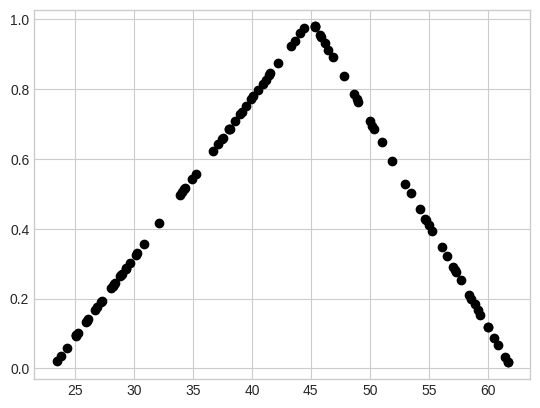

In [6]:
n = 100

sampler = build_sampleable_triangular_mf(23, 45, 62)
mf = build_triangular_mf(23, 45, 62)
x = [sampler(rm(), rm()) for i in range(n)]
y = [mf(u) for u in x]
plt.plot(x, y, 'o', color='black')

## Cumulative membership function-based
From "Fuzzy Uncertainty in Random Variable Generation: A Cumulative Membership
Function Approach", by Diana Giseth Pulido-L´opez, Mabel García, and Juan Carlos Figueroa-García

In [7]:
def build_trapezoidal_mf(a, b, c, d):
  if a > b or b > c or c > d:
    raise ValueError("Parameters must form a nondecreasing sequence")
  return lambda x: (x-a)/(b-a) if a <= x < b else 1 if b <= x < c else (d - x)/(d - c) if c <= x < d else 0

def build_sampleable_trapezoidal_mf(a, b, c, d):
  if a > b or b > c or c > d:
    raise ValueError("Parameters must form a nondecreasing sequence")
  Lambda1 = (b - a) / 2
  Lambda2 = c - b
  Lambda3 = (d - c) / 2
  Lambda = (c + d - a - b) / 2

  lambda1 = Lambda1 / Lambda
  lambda2 = Lambda2 / Lambda
  lambda3 = Lambda3 / Lambda

  return lambda u: a + math.sqrt((b - a) * 2 * u * Lambda) if u <= lambda1 else u * Lambda + b - Lambda1 if u <= (lambda1 + lambda2) else d - math.sqrt((d - c)**2 - 2 * (d - c) * (u * Lambda - Lambda1 - Lambda2))


In [8]:
sampler = build_sampleable_trapezoidal_mf(23, 45, 62, 98)
mf = build_trapezoidal_mf(23, 45, 62, 98)

for j in range(100):
  r = sampler(rm())
  print("({}, {})".format(r, mf(r)))

(81.8282286818093, 0.4492158699497415)
(83.49017882412134, 0.40305058821885154)
(33.8016120806077, 0.4909823673003499)
(64.4538127058519, 0.9318385359485583)
(42.1645313816863, 0.8711150628039228)
(79.36748779572727, 0.5175697834520202)
(42.130274519928406, 0.8695579327240185)
(49.45629328168426, 1)
(39.936907771587684, 0.7698594441630765)
(33.788710741932675, 0.4903959428151216)
(57.32752496407279, 1)
(70.39794743790858, 0.7667236822803171)
(33.764605604097724, 0.48930025473171473)
(58.51870365514759, 1)
(41.43092071250335, 0.8377691232956068)
(52.12690537546837, 1)
(56.70774619838852, 1)
(79.92084576568979, 0.5021987287308392)
(60.50792508240319, 1)
(74.49641957500707, 0.6528772340275815)
(56.88048061983136, 1)
(49.02246844922767, 1)
(72.61396331609451, 0.7051676856640413)
(51.36389232871532, 1)
(50.09086655633237, 1)
(58.448167086892994, 1)
(56.54286591099705, 1)
(65.64870056674661, 0.8986472064792608)
(57.77808843905083, 1)
(86.74703287799072, 0.3125824200558134)
(36.0917632147884,

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
import numpy as np

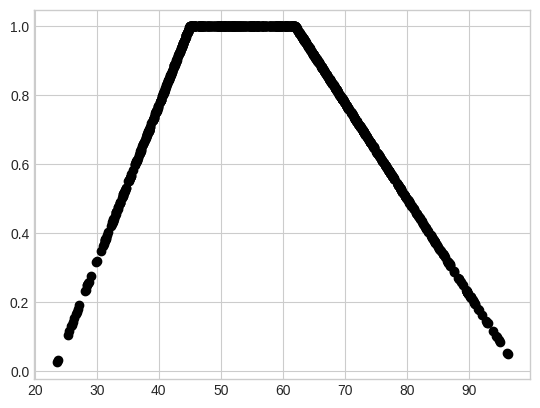

In [10]:
n = 1000
x = [sampler(rm()) for i in range(n)]
y = [mf(u) for u in x]
plt.plot(x, y, 'o', color='black')

#**Simulación de una instancia de VRP utilizando Simpy**

Características:

*   1 vehiculo con límite de capacidad.
*   1 depósito (inicio y fin del recorrido).
*   N clientes.
*   Se posee una estimación de las demandas de los clientes y del tiempo de recorrido entre cada uno de ellos incluído el depósito.
*   La simulación finaliza al regresar al depósito.





## Instalación e importación de librerías necesarias

In [11]:
#!pip install simpy
#!pip install pandas

In [12]:
import simpy
import random
import numpy as np
import pandas as pd

In [13]:
np. __version__

'1.26.4'

## Definicion e inicializacion de estructuras de datos



### Samplers for Random Fuzzy Number Generator

In [14]:
sampler_triangular = build_sampleable_triangular_mf(0.3, 0.7, 3.0)
sampler_trapezoidal_prod_pedido = build_sampleable_trapezoidal_mf(30, 45, 55, 75)
sampler_trapezoidal_prod_estimado = build_sampleable_trapezoidal_mf(30, 35, 50, 60)

In [15]:
sampler_trapezoidal_prod_estimado(rm())
#sampler_triangular(rm(),rm())

47.32070966825908

###Tabla de distancias/tiempos estimados entre los clientes, incluyendo el deposito

In [16]:
# Importar matriz de adyacencia desde csv
#df = pd.read_csv('VRP-data - 2.csv',sep=";")
#df.index = df.columns
#df

In [17]:
ubicaciones = ['Frigorifico Tres Arroyos', 'La Blanq y D Gaspar', 'D Gaspar y La Blanquita', 'Rougier Carnes', 'La Pulperia',
       'Granja de Rosso', 'La Estancia', 'El Buen Trato', 'El Ternero Gasolero', 'La Imbatible', 'El tropezon',
       'Estancia La Argentina', 'La Providencia', 'Don Miguel', 'El Gauchito', 'Del Campo Carnes', 'El mejor corte',
       'Lo de gaston Araoz', 'Lo de gaston ruta', 'La Campeira', 'Don Adolfo']

tiempos = np.array([[ 0,  9,  6,  4,  4,  7,  9, 10, 12, 10,  8, 10, 10, 12, 12, 12,
         6,  7,  6,  9, 12],
       [ 8,  0,  5,  8,  8,  9,  9, 10, 11,  9,  9, 12, 12, 11, 13, 14,
         5, 10,  6, 16, 14],
       [ 6,  6,  0,  5,  5,  5,  5,  8,  7,  5,  7,  6,  7,  7,  8,  9,
         2,  6,  3, 10,  8],
       [ 4,  8,  5,  0,  1,  4,  5,  5,  7,  6,  8,  5,  7,  8,  3,  5,
         5,  6,  7, 12,  7],
       [ 5,  9,  6,  3,  0,  5,  7,  6,  8,  7,  6,  9,  9, 10, 10, 10,
         6,  6,  6,  7, 10],
       [ 7,  9,  6,  5,  5,  0,  4,  3,  5,  4,  3,  5,  5,  5,  6,  7,
         6,  1,  6,  7,  6],
       [ 8,  9,  5,  6,  5,  2,  0,  5,  4,  2,  4,  3,  4,  4,  5,  7,
         5,  3,  6,  8,  4],
       [ 9, 12,  9,  7,  6,  5,  6,  0,  5,  7,  3,  7,  5,  5,  8,  8,
        10,  5, 10,  4,  6],
       [10, 11,  7,  8,  7,  5,  4,  3,  0,  4,  4,  3,  2,  1,  4,  4,
         8,  5,  9,  6,  3],
       [ 9,  9,  6,  7,  6,  5,  3,  7,  6,  0,  6,  3,  5,  5,  3,  5,
         5,  5,  7, 10,  4],
       [ 7, 10,  6,  7,  4,  2,  4,  3,  5,  5,  0,  5,  5,  5,  7,  8,
         7,  2,  7,  6,  6],
       [ 9, 12,  6,  3,  6,  4,  2,  8,  4,  1,  5,  0,  4,  6,  3,  4,
         6,  4,  7, 10,  3],
       [ 9, 12,  7,  6,  6,  4,  4,  4,  3,  4,  3,  4,  0,  2,  5,  5,
         8,  4,  8,  7,  4],
       [10, 13,  9,  8,  7,  5,  6,  2,  4,  6,  4,  5,  3,  0,  6,  6,
        10,  5, 10,  6,  5],
       [12, 13,  8,  5,  9,  6,  5,  7,  5,  3,  6,  3,  5,  5,  0,  2,
         9,  7,  9,  8,  3],
       [12, 14,  8,  5,  9,  6,  4,  5,  4,  3,  6,  3,  4,  4,  4,  0,
         8,  7,  9,  8,  2],
       [ 6,  5,  2,  5,  6,  7,  5,  9,  8,  7,  8,  7,  8,  8,  9, 10,
         0,  7,  2, 12,  9],
       [ 6,  8,  5,  5,  4,  1,  3,  4,  5,  4,  3,  4,  5,  5,  6,  7,
         6,  0,  5,  6,  6],
       [ 7,  3,  4,  8,  8,  8,  9, 12, 12, 10, 10,  9,  9, 10, 10, 12,
         4,  8,  0, 12, 10],
       [ 9, 14, 10, 10,  6,  6,  8,  4,  5,  8,  6,  8,  6,  6,  9,  8,
        12,  7, 12,  0,  7],
       [12, 14,  8,  5,  9,  6,  4,  6,  3,  3,  7,  3,  5,  4,  4,  3,
         8,  7, 10,  7,  0]])
df_tiempos = pd.DataFrame(tiempos, columns=ubicaciones, index=ubicaciones)
df_tiempos

,Frigorifico Tres Arroyos,La Blanq y D Gaspar,D Gaspar y La Blanquita,Rougier Carnes,La Pulperia,Granja de Rosso,La Estancia,El Buen Trato,El Ternero Gasolero,La Imbatible,...,Estancia La Argentina,La Providencia,Don Miguel,El Gauchito,Del Campo Carnes,El mejor corte,Lo de gaston Araoz,Lo de gaston ruta,La Campeira,Don Adolfo
Frigorifico Tres Arroyos,0,9,6,4,4,7,9,10,12,10,...,10,10,12,12,12,6,7,6,9,12
La Blanq y D Gaspar,8,0,5,8,8,9,9,10,11,9,...,12,12,11,13,14,5,10,6,16,14
D Gaspar y La Blanquita,6,6,0,5,5,5,5,8,7,5,...,6,7,7,8,9,2,6,3,10,8
Rougier Carnes,4,8,5,0,1,4,5,5,7,6,...,5,7,8,3,5,5,6,7,12,7
La Pulperia,5,9,6,3,0,5,7,6,8,7,...,9,9,10,10,10,6,6,6,7,10
Granja de Rosso,7,9,6,5,5,0,4,3,5,4,...,5,5,5,6,7,6,1,6,7,6
La Estancia,8,9,5,6,5,2,0,5,4,2,...,3,4,4,5,7,5,3,6,8,4
El Buen Trato,9,12,9,7,6,5,6,0,5,7,...,7,5,5,8,8,10,5,10,4,6
El Ternero Gasolero,10,11,7,8,7,5,4,3,0,4,...,3,2,1,4,4,8,5,9,6,3
La Imbatible,9,9,6,7,6,5,3,7,6,0,...,3,5,5,3,5,5,5,7,10,4


### Tabla de Planificacion inicial de orden de visita, con estimacion de cantidad de productos requeridos

In [18]:
#Uncertainty: 
############[1: low, 2: medium, 3: high]
def estimar(clientes, uncertainty=1):
  estimaciones = np.empty((0, 4), dtype=int)
  for i in clientes[1:len(clientes)]:
    delta= 0 #int(random.uniform(0,20))
    if uncertainty==3: #HU
      a = int(random.uniform(30,33)) + delta
      b = int(random.uniform(43,55)) + delta
      c = int(random.uniform(56,62)) + delta
      d = int(random.uniform(77,83)) + delta
    elif uncertainty==2: #MU
      a = int(random.uniform(35,40)) + delta
      b = int(random.uniform(45,55)) + delta
      c = int(random.uniform(56,60)) + delta
      d = int(random.uniform(65,70)) + delta
    else: #LU
      a = int(random.uniform(45,48)) + delta
      b = int(random.uniform(49,53)) + delta
      c = int(random.uniform(54,58)) + delta
      d = int(random.uniform(59,61)) + delta
    estimaciones = np.append(estimaciones, np.array([[a,b,c,d]]), axis=0)
  return estimaciones

In [19]:
#Uncertainty: 
############[1: low, 2: medium, 3: high]
def planificacion(clientes, uncertainty=1):
  data_plan = np.empty((0, 10))
  estimaciones = estimar(clientes,uncertainty)
  n=1
  for i in clientes[1:len(clientes)]:
    sampler_trapezoidal = build_sampleable_trapezoidal_mf(estimaciones[n-1][0], estimaciones[n-1][1], estimaciones[n-1][2], estimaciones[n-1][3])
    estimado = int(sampler_trapezoidal(rm()))
    pedido = int(sampler_trapezoidal(rm())) #int(random.uniform(0.8,1.2)*estimado)
    data_plan = np.append(data_plan, np.array([[i,n, estimaciones[n-1][0], estimaciones[n-1][1], estimaciones[n-1][2], estimaciones[n-1][3], estimado, 0 ,pedido,0]]), axis=0)
    n=n+1
  plan = pd.DataFrame(data_plan, columns=['cliente','idCliente','estimacionA','estimacionB','estimacionC','estimacionD','productosEstimados','productosPedidosConocido','productosPedidos','productosRecibidos'])
  return plan

In [20]:
planificacion(ubicaciones)

,cliente,idCliente,estimacionA,estimacionB,estimacionC,estimacionD,productosEstimados,productosPedidosConocido,productosPedidos,productosRecibidos
0,La Blanq y D Gaspar,1,45,50,55,59,49,0,48,0
1,D Gaspar y La Blanquita,2,46,52,54,59,53,0,56,0
2,Rougier Carnes,3,45,49,56,60,47,0,50,0
3,La Pulperia,4,45,51,55,59,52,0,49,0
4,Granja de Rosso,5,45,50,55,59,47,0,53,0
5,La Estancia,6,47,52,55,60,55,0,51,0
6,El Buen Trato,7,46,50,56,60,56,0,49,0
7,El Ternero Gasolero,8,47,52,54,59,53,0,53,0
8,La Imbatible,9,46,52,54,59,52,0,48,0
9,El tropezon,10,46,51,55,60,57,0,53,0


In [21]:
df = planificacion(ubicaciones)
df[df.productosPedidos == df.productosRecibidos].shape[0]

0

### Tabla de "registro de viaje"

*   Orden de visita real
*   Confirmacion de atencion
*   Duracion del viaje
*   Tiempos de llegada
*   Tiempo de atencion
*   Cantidad de pedido real (en el momento)
*   Cantidad de productos realmente entregados

In [22]:
#data_viaje = np.array([0,0,0,0,0,0,0,0]) # se cargaria durante la simulacion
df_viaje =  pd.DataFrame( columns=['Cliente','orden_visita_real','duracion_viaje','tiempo_llegada','duracion_espera','posponer','tiempo_atencion','pedido','duracion_atencion','entregar','entregado'])
df_viaje

,Cliente,orden_visita_real,duracion_viaje,tiempo_llegada,duracion_espera,posponer,tiempo_atencion,pedido,duracion_atencion,entregar,entregado


## Implementación de la clase 'Vehicle'

Esta clase define e implementa la lógica de la simulación.
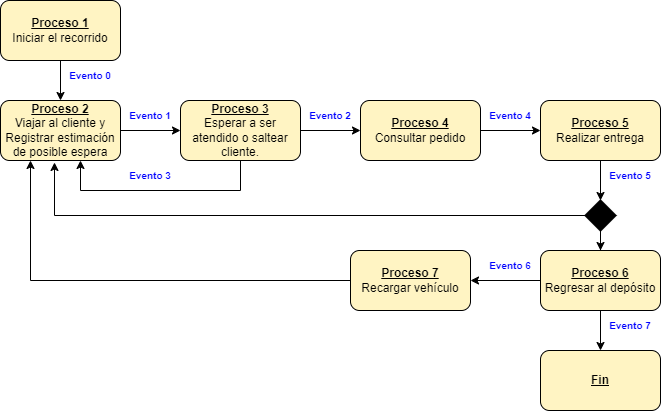

In [23]:
class Vehicle(object):
    def __init__(self, env, capacity, available_products, times_map, planning, warehouse, max_time=360):
        self.env = env
        #self.vehicle = simpy.Resource(env, num_vehicles)
        self.available_products = available_products
        self.capacity = capacity
        self.travel_time = 0
        self.times_map_base = times_map.copy()
        self.current_times_map = self.times_map_base.copy()
        self.time_block = 0 # sin actualizacion de tiempos   #1
        self.planning = planning.copy()
        self.planning = self.planning.sort_values('idCliente')
        self.trip_log = pd.DataFrame( columns=['Cliente', 'idCliente', 'orden_visita_real','duracion_viaje','tiempo_llegada','duracion_espera','posponer','tiempo_atencion','pedido','duracion_atencion','entregar','entregado'])
        self.warehouse = warehouse
        self.current_location = warehouse
        self.customers_visited = 0
        self.current_event= ''
        self.current_time=''
        self.current_customerId = None
        self.cancel = 0
        self.endTour = 0
        self.next_customer = 1
        self.max_time = max_time
        self.sampler_unloading_time = build_sampleable_triangular_mf(5, 6, 7)

    def set_next_customer(self, id_customer):
        self.next_customer = id_customer

    def update_current_time_map(self,a,b):
      #times_change = np.random.uniform(0.8,1.7,len(self.times_map_base.to_numpy()[0]))
      times_change = np.random.uniform(a,b,len(self.times_map_base.to_numpy()[0]))
      self.current_times_map = times_change * self.times_map_base.copy()

    def run (self,env):
        initial_time = self.env.now
        total_travel_time = self.env.now - initial_time
        self.current_event = 0 #'inicio'

        #realizar el recorrido visitando los clientes (mientras no se supere el tiempo maximo o no se haya concluido el trabajo)
        trip_number=0
        while (self.endTour!=1 and total_travel_time<self.max_time):
          # Actualización de tiempos de viaje
          # self.time_block sirve para que la actualización se realice solo la primera vez que la simulación entra al rango de tiempo.
          if (total_travel_time in range(90,180) and self.time_block==1):
            self.update_current_time_map(0.8,1.2)
            self.time_block = 2
          elif (total_travel_time in range(150,270) and self.time_block==2):
            self.update_current_time_map(1.4,2)
            self.time_block = 3
          elif (total_travel_time in range(270,360) and self.time_block==3):
            self.update_current_time_map(0.9,1.2)
            self.time_block = 4

          self.cancel = 0
          trip_number += 1
          #print("Tiempo act: ",total_travel_time,"  Cliente= ", self.next_customer," Mercaderia: ",self.available_products)

          if (self.next_customer==0 or self.available_products==0):
            #volver al deposito a recargar productos
            #print(self.current_location)
            trip_duration = self.current_times_map.loc[self.current_location].loc[self.warehouse] #tiempo de viaje desde la ubicacion actual al deposito
            #Si se viaja al deposito y ya esta en el deposito, se toma como una espera/ descanso y se adelanta 15 minutos la simulación.
            if (trip_duration ==0):
              trip_duration = 15
            #print("tiempo de viaje al deposito: ", trip_duration)

            yield self.env.timeout(trip_duration)
            self.current_event = 6 #'recargar'
            self.available_products = self.capacity
            recharge_time = int(self.capacity * self.sampler_unloading_time(rm(),rm()) / 60 /2)

            yield self.env.timeout(recharge_time)
            # Crear el registro en trip_log
            self.customers_visited = self.customers_visited + 1
            #'Cliente','idCliente', 'orden_visita_real','duracion_viaje','tiempo_llegada','duracion_espera','posponer','tiempo_atencion','pedido','duracion_atencion','entregar','entregado'
            self.trip_log.loc[self.customers_visited] = (self.warehouse, 0, self.customers_visited, trip_duration, self.env.now, 0,0,recharge_time,0,0,0,0)

            self.current_location = self.warehouse
            self.current_time= self.env.now

          else:
            self.current_customerId = self.next_customer
            customer= self.planning.sort_index().at[self.current_customerId -1,"cliente"]

            yield self.env.process(self.travel_next_customer(customer))

            #En esta version no se considera la espera
            #yield self.env.process(self.wait_customer(customer))
            if (self.cancel == 0):
              yield self.env.process(self.check_order(customer))
              yield self.env.process(self.deliver_products(customer))


          total_travel_time = self.env.now - initial_time
          #yield self.env.timeout(1)

          pedido = self.planning['productosPedidos'].to_numpy(dtype=int)
          entregado = self.planning['productosRecibidos'].to_numpy(dtype=int)
          if(sum(pedido-entregado)==0): #SI TODOS LOS CLIENTES FUERON SATISFECHOS
            self.endTour=1

        #volver al deposito
        trip_duration = self.current_times_map.loc[self.current_location].loc[self.warehouse] #tiempo de viaje desde la ubicacion actual al deposito
        yield self.env.timeout(trip_duration)
        # Crear el registro en trip_log
        self.customers_visited = self.customers_visited + 1
        #'Cliente','idCliente', 'orden_visita_real','duracion_viaje','tiempo_llegada','duracion_espera','posponer','tiempo_atencion','pedido','duracion_atencion','entregar','entregado'
        self.trip_log.loc[self.customers_visited] = (self.warehouse, 0, self.customers_visited, trip_duration, self.env.now, 0,0,0,0,0,0,0)
        self.current_event = 7 #'fin'
        self.current_location = self.warehouse

        total_travel_time = self.env.now - initial_time
        #print(self.planning.sort_index().to_string()) #.sort_index()
        #print(self.trip_log.to_string())
        #print("Tiempo total de viaje: ",total_travel_time)

    def travel_next_customer(self, customer):
        initial_travel_time = self.env.now
        #print('Viajando a %s' % customer)

        # Generar el tiempo de viaje desde la ubicacion actual al proximo cliente.
        travel_time = self.current_times_map.loc[self.current_location].loc[customer]

        #Si se viaja al mismo cliente en el que se está, se toma como una espera/ descanso y se adelanta 10 minutos la simulación.
        if (travel_time ==0):
          travel_time = 10
          #self.cancel = 1

        yield self.env.timeout(travel_time)

        #print('Arribo a %s' % customer)

        self.customers_visited = self.customers_visited + 1
        self.current_event = 1 # ('travel-'+str(self.customers_visited+1))

        # Geenrar estimacion de espera / En esta version no se considera la espera
        #wait_estimated = random.uniform(1,5)  # Revisar distribucion
        wait_estimated = 0

        # Crear el registro en trip_log
        #'Cliente','idCliente', 'orden_visita_real','duracion_viaje','tiempo_llegada','duracion_espera','posponer','tiempo_atencion','pedido','duracion_atencion','entregar','entregado'
        self.trip_log.loc[self.customers_visited] = (customer, self.current_customerId, self.customers_visited, travel_time, self.env.now, wait_estimated,0,0,0,0,0,0)

        #Actualizar la ubicacion y la hora actual
        self.current_location = customer
        self.current_time= self.env.now

    def wait_customer(self, customer):   # ver como modificarlo para que pueda haber una consulta/decision
        if (self.trip_log.at[self.customers_visited, 'posponer'] == 0):
          yield self.env.timeout(self.trip_log.at[self.customers_visited, 'duracion_espera'])
          self.current_event = 2 #'wait-'+str(self.customers_visited)
        else:
          self.cancel == 1
          self.current_event = 3 #'salteado-'+str(self.customers_visited)
        self.current_time= self.env.now

    def check_order(self, customer):
        #print('Consultando pedido en %s' % customer)

        #actualizamos productosPedidosConocido
        self.planning.at[self.current_customerId-1,"productosPedidosConocido"] = self.planning.at[self.current_customerId-1,"productosPedidos"]

        pedido_inicial = int(self.planning.sort_index().at[self.current_customerId -1,"productosPedidos"])
        recibido_actual = int(self.planning.sort_index().at[self.current_customerId -1,"productosRecibidos"])
        pedir = pedido_inicial - recibido_actual

        self.trip_log.at[self.customers_visited, 'pedido'] = pedir

        yield self.env.timeout(1/60)

        self.current_event = 4 #'check_order-'+str(self.customers_visited)

        self.current_time= self.env.now


    def deliver_products(self, customer):
        # Entregar productos, registrar y actualizar variables
        entregar = int(self.trip_log.at[self.customers_visited, 'entregar'])
        if (entregar>self.available_products):
          entregar = self.available_products

        deliver_time = int(entregar * self.sampler_unloading_time(rm(),rm()) / 60)

        self.available_products = self.available_products - entregar
        self.trip_log.at[self.customers_visited, 'duracion_atencion'] = deliver_time
        self.trip_log.at[self.customers_visited, 'entregado'] = entregar

        recibido_ant = int(self.planning.sort_index().at[self.current_customerId -1,'productosRecibidos'])
        recibido = recibido_ant + entregar

        self.planning = self.planning.sort_index()
        self.planning.at[self.current_customerId-1,'productosRecibidos'] = recibido

        yield self.env.timeout(abs(deliver_time))

        self.current_event = 5  #'deliver_products-'+str(self.customers_visited)
        self.current_time= self.env.now


## Pruebas de la simulación

In [24]:
df_planificacion = planificacion(ubicaciones)

capacity_vehicle_1 = 400
available_products_vehicle_1 = 350
warehouse_vehicle_1 = ubicaciones[0] #la primer ubicacion se toma como el depósito
current_time=''
current_event= ''
current_location = warehouse_vehicle_1


In [25]:
env = simpy.Environment()
vehicle_1 = Vehicle(env, capacity_vehicle_1, available_products_vehicle_1, df_tiempos, df_planificacion, warehouse_vehicle_1)
env.process(vehicle_1.run(env))
#env.run(until=140)
env.step()
event = new_event= vehicle_1.current_event
print(event)
print(env.peek())
print(env.step())

0
0
None


In [26]:
#print(vehicle_1.planning.sort_index())
print(vehicle_1.planning)


                    cliente idCliente estimacionA estimacionB estimacionC  \
0       La Blanq y D Gaspar         1          45          51          57   
9               El tropezon        10          47          50          57   
10    Estancia La Argentina        11          46          51          56   
11           La Providencia        12          47          51          57   
12               Don Miguel        13          46          49          56   
13              El Gauchito        14          45          49          56   
14         Del Campo Carnes        15          47          51          54   
15           El mejor corte        16          46          50          54   
16       Lo de gaston Araoz        17          46          50          55   
17        Lo de gaston ruta        18          45          50          54   
18              La Campeira        19          46          50          57   
1   D Gaspar y La Blanquita         2          46          51          54   

In [27]:
until = 50
while (event == new_event) and (env.peek() < until): # "env.peek() < until" controla que no haya llegado al fin la ejecucion (peek da el tiempo del proximo evento)
     env.step()
     new_event= vehicle_1.current_event
    #event = vehicle_1.current_event
event = new_event
print(event)
print('tiempo actual:')
print(vehicle_1.current_time)


1
tiempo actual:
9


In [28]:
vehicle_1.current_event
vehicle_1.customers_visited


1

In [29]:
vehicle_1.trip_log

,Cliente,idCliente,orden_visita_real,duracion_viaje,tiempo_llegada,duracion_espera,posponer,tiempo_atencion,pedido,duracion_atencion,entregar,entregado
1,La Blanq y D Gaspar,1,1,9,9,0,0,0,0,0,0,0


______________________________
# **Ensamble en un Python Environment de TF-Agents**

Ensamble de la simulación de la instancia VRP en un Python Environment de TF-Agents

## Instalación e importación de librerías necesarias

In [30]:
#!pip install --upgrade pip
#!sudo apt-get update
#!pip install tensorflow-gpu==2.17.0
#
#
#!pip install tf-keras
#!pip install tf-agents[reverb]

In [31]:
import os
# Keep using keras-2 (tf-keras) rather than keras-3 (keras).
os.environ['TF_USE_LEGACY_KERAS'] = '1'

In [32]:
#!pip install --upgrade pip
#!pip install --upgrade tensorflow
#!pip install tensorflow[and-cuda]==2.15.0
#!pip install tensorflow[and-cuda]
#!pip install tensorflow==2.15.0
#!pip install tf-agents

# Newer versions of tensorflow-probability require newer versions of TensorFlow.
#!pip install tensorflow-probability==0.8.0
#!pip install tf-agents==0.19.0
#!pip install --user tf-agents[reverb]
!pip install tf-agents[reverb]


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [33]:
#!pip install --upgrade tensorflow-probability

In [34]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

2025-10-01 15:48:50.401233: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-01 15:48:50.427378: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-01 15:48:50.427402: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-01 15:48:50.428008: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-01 15:48:50.432242: I tensorflow/core/platform/cpu_feature_guar

1 Physical GPUs, 1 Logical GPUs


2025-10-01 15:48:51.450114: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-10-01 15:48:51.472291: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-10-01 15:48:51.473292: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [35]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import abc
import tensorflow as tf
#import numpy as np
#import tf_agents

from tf_agents.environments import py_environment
from tf_agents.environments import tf_environment
from tf_agents.environments import tf_py_environment
from tf_agents.environments import utils
from tf_agents.specs import array_spec
#from tf_agents.environments import wrappers
#from tf_agents.environments import suite_gym
from tf_agents.trajectories import time_step as ts
from tf_agents.trajectories.time_step import StepType
from tf_agents.trajectories.time_step import TimeStep


In [36]:
import networkx as nx
from karateclub import DeepWalk

from karateclub import GL2Vec
from karateclub import Graph2Vec
from karateclub import WaveletCharacteristic
import pickle

/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## Implementación de la clase 'VRPEnv'

Esta clase implementa un entorno para aprendizaje por refuerzo utilizando la API de PyEnvironment de la librería TF-Agents.
Si RL = False, el entorno adapta las observaciones para un Agente basado en optimización por colonia de hormigas.
Si RL = True, el entorno adapta las observaciones para un Agente basado en Aprendizaje por Refuerzo (RL).



Este entorno implementa un problema VRP de entrega de mercadería.
El objetivo es que el agente entrene una política que controlará el vehículo para que visite a los clientes y entregue la mercadería, buscando minimizar el tiempo de recorrido y maximizar la satisfacción de los clentes (cumplir con la demanda). El vehículo tiene una restricción de capacidad y un tiempo esperado de viaje.

En cada episodio el vehículo parte del depósito y finaliza el recorrido al regresar al mismo. El retorno será **( ..... completar)**

In [37]:
demandas = np.array([1,0,1,0,2,2,2,3,4,0,0,0,2,3,0], dtype= np.int32)

active_customers = np.where(demandas>0,np.ones(15, dtype= np.int32),np.zeros(15, dtype= np.int32))
active_customers

array([1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0], dtype=int32)

In [38]:
class VRPEnv(py_environment.PyEnvironment):

  def update_valid_actions(self):
    self.valid_actions = np.zeros((1,self.actions), dtype= np.int32)

    #REVISAR ESTO
    self.valid_actions[0][2:4]=1  # acciones de entrega validas

    if (self.vehicle.available_products<30): #REVISAR ESTO
        self.valid_actions[0][self.max_ubicaciones+1:self.max_ubicaciones+2]= 1 #se puede viajar al deposito

    """
    a = np.array([], dtype= np.int32)
    for ind in self.vehicle.planning.set_index('idCliente').index:
          if (int(self.vehicle.planning.set_index('idCliente')['productosPedidos'][ind]) - int(self.vehicle.planning.set_index('idCliente')['productosRecibidos'][ind]) <=0):
            a = np.append(a, 0)
          else:
            a = np.append(a, 1)
    """
    #print(self.vehicle.planning.sort_index())
    Estimado =  self.vehicle.planning.sort_index()['productosEstimados'].to_numpy(dtype=int)
    PedidoConocido = self.vehicle.planning.sort_index()['productosPedidosConocido'].to_numpy(dtype=int)
    Recibido = self.vehicle.planning.sort_index()['productosRecibidos'].to_numpy(dtype=int)
    self.demandas = np.where(PedidoConocido==0,Estimado,PedidoConocido) - Recibido

    active_customers = np.where(self.demandas>0,np.ones(self.customers, dtype= np.int32),np.zeros(self.customers, dtype= np.int32))
    #print("active customers: ", active_customers)
    #self.valid_actions[0][self.customers+2:self.actions]= active_customers #a #clientes que todavía no estan satisfechos
    self.valid_actions[0][self.max_ubicaciones+2:self.max_ubicaciones+2+len(active_customers)]= active_customers #clientes que todavía no estan satisfechos
    #print("Valid Actions: ", self.valid_actions[0])



  def update_metrics(self):
    #pedido = self.vehicle.trip_log['pedido'].to_numpy(dtype=int)
    #entregado = self.vehicle.trip_log['entregado'].to_numpy(dtype=int)

    # Final Environment reward (ya se va autosumando en el desarrollo)
    ##

    # Percentage of satisfied customers
    #self.satisfied_customers =  (self.vehicle.planning[self.vehicle.planning.productosPedidosConocido == self.vehicle.planning.productosRecibidos].shape[0]) #/ self.vehicle.planning.shape[0] *100
    Estimado =  self.vehicle.planning.sort_index()['productosEstimados'].to_numpy(dtype=int)
    PedidoConocido = self.vehicle.planning.sort_index()['productosPedidosConocido'].to_numpy(dtype=int)
    Recibido = self.vehicle.planning.sort_index()['productosRecibidos'].to_numpy(dtype=int)
    self.demandas = np.where(PedidoConocido==0,Estimado,PedidoConocido) - Recibido
    self.satisfied_customers = (self.customers - np.count_nonzero(self.demandas)) # /self.customers *100

    # Percentage of customers without deliveries
    #self.customers_without_deliveries = (self.vehicle.planning[self.vehicle.planning.productosRecibidos == 0].shape[0]) #/ self.vehicle.planning.shape[0] *100

    self.customers_without_deliveries = (self.customers - np.count_nonzero(Recibido)) #/self.customers *100



    # Total time
    self.total_time = self.vehicle.current_time
    # Final satisfaction without discounts
    self.total_satisfaction = sum(Recibido)/sum(np.where(PedidoConocido==0,Estimado,PedidoConocido)) # * 100

    # Number of visits to the warehouse
    self.wharehouse_visits = self.vehicle.trip_log[self.vehicle.trip_log.Cliente == self.warehouse_vehicle].shape[0]
    # Number of trips
    self.trips = len(self.vehicle.trip_log)


  def get_metrics(self):
    metrics = dict(Total_reward = self.total_reward,
                   Satisfied_customers = self.satisfied_customers,
                   Customers_without_deliveries = self.customers_without_deliveries,
                   Total_time = self.total_time,
                   Total_satisfaction = self.total_satisfaction,
                   Wharehouse_visits = self.wharehouse_visits,
                   Trips = self.trips)

    return metrics


  def load_embedding_model(self, embedding_method):
    filename = 'trained_WaveletCharacteristic_model.sav'
    if embedding_method == 'wavelets':
        filename = 'trained_WaveletCharacteristic_model.sav'
    elif embedding_method == 'graph2vec':
         filename = 'trained_Graph2Vec_model.sav'
    elif embedding_method == 'gl2vec':
        filename = 'trained_GL2Vec_model.sav'
    # load the model from disk
    return pickle.load(open(filename, 'rb'))




  def get_actual_embedding(self):
    #crear el grafo
    matriz = self.vehicle.current_times_map.to_numpy(dtype=np.int32)
    plan = self.vehicle.planning[['idCliente','estimacionA','estimacionB','estimacionC','estimacionD','productosEstimados','productosPedidosConocido','productosRecibidos']]

    G = nx.from_numpy_array(matriz)
    G.nodes[0]['demanda'] = 0 #DEPOSITO
    G.nodes[0]['productosRecibidos'] = 0 #DEPOSITO

    for i in range(1,len(G.nodes)):
        estimacion = int(plan.at[i-1,"productosEstimados"])
        pedido = int(plan.at[i-1,"productosPedidosConocido"])
        #si se conoce la cantidad pedida por el cliente se toma ese valor, sino la cantidad estimada.
        if pedido>0 :
            G.nodes[i]['demanda'] = pedido
        else:
            G.nodes[i]['demanda'] = estimacion
        G.nodes[i]['productosRecibidos'] = int(plan.at[i-1,"productosRecibidos"])

    #generar el embedding del grafo
    embedding = self.embedding_model.infer([G])[0] #.to_numpy(dtype=np.float_)
    #embedding = np.zeros((self.embedding_len,), dtype= np.float_)
    return embedding


   # Uncertainty: [1: low, 2: medium, 3: high]
   # embedding_method: ['wavelets', 'graph2vec', 'gl2vec']
  def __init__(self, ubicaciones, max_time=480, elapsed_time_discount=0.9, RL=True, dinamic_times=False, uncertainty=1, max_ubicaciones = 50, embedding_method = 'wavelets'):
    self.ubicaciones = ubicaciones
    self.RL = RL
    self.dinamic_times =dinamic_times
    self.uncertainty = uncertainty
    self.max_ubicaciones = max_ubicaciones
    self.embedding_model = self.load_embedding_model(embedding_method)
    self.embedding_len = len(self.embedding_model.get_embedding()[0])

    self.planning = planificacion(self.ubicaciones,self.uncertainty)
    self.max_time = max_time
    #elapsed time discount parameter
    self.elapsed_time_discount = elapsed_time_discount
    self.customers = len(self.planning.index)
    

    self.capacity_vehicle = 400
    self.available_products_vehicle = 350
    self.warehouse_vehicle = self.ubicaciones[0]

    ##METRICS
    # Final Environment reward
    self.total_reward = 0
    # Percentage of satisfied customers
    self.satisfied_customers = 0
    # Percentage of customers without deliveries
    self.customers_without_deliveries = 0
    # Total time
    self.total_time = 0
    # Final satisfaction without discounts
    self.total_satisfaction = 0
    # Number of visits to the warehouse
    self.wharehouse_visits = 0
    # Number of trips
    self.trips = 0

    self.env = simpy.Environment()
    self.vehicle = Vehicle(self.env, self.capacity_vehicle, self.available_products_vehicle, df_tiempos, self.planning, self.warehouse_vehicle, self.max_time)

    if(self.dinamic_times): self.vehicle.time_block = 1
    if(self.uncertainty==3): self.vehicle.sampler_unloading_time = build_sampleable_triangular_mf(5, 8, 11)
    elif(self.uncertainty==2): self.vehicle.sampler_unloading_time = build_sampleable_triangular_mf(5, 7, 8)

    #self.actions = 2*(self.customers+1)
    self.actions = 2*(self.max_ubicaciones + 1)
    self.update_valid_actions()

    #Componentes de la acción/decisión:
    #1- Define la cantidad de productos a entregar a un cliente.
        # Cambiar a Opciones: 0:no entregar; 1:entregar la mitad de lo pedido; 2:entregar solo lo estimado;  3:entregar lo solicitado
    #2- Define el proximo destino
    """ self._action_spec = array_spec.BoundedArraySpec(
        shape=(2,), dtype=np.int32, minimum=[0,0], maximum=[2,self.customers], name='action') """

    self._action_spec = array_spec.BoundedArraySpec(
        shape=(2,), dtype=np.int32, minimum=[0,0], maximum=[self.max_ubicaciones,self.max_ubicaciones], name='action')


    self.valid_action_spec = array_spec.BoundedArraySpec(
        shape=(1,self.actions), dtype=np.int32, minimum=0, maximum=1, name='valid_actions') ## Tiene que ser un vector plano o tienen que ser uno por cada accion ????

    #Datos que ve el agente en cada paso:
    #1- Evento:
        #0: Inicio del recorrido
        #1: llegada al cliente
        #2: termina espera y es atendido
        #3: cliente salteado (indica cómo reorganiza??)
        #4: pedido registrado
        #5: entrega realizada
        #6: recarga en deposito
        #7: Fin del reccorrido
    #2- Número del Cliente actual
    #3- Tiempo actual
    #4- Mercadería disponible
    #5- Pedido del cliente (si corresponde, sino 0)
    #6- Estimado (Estimado inicial - recibido actual)

    #OBSERVACION BASE
    general_obs_spec= array_spec.BoundedArraySpec(
        shape=(6,), dtype=np.float_, minimum=0, name='general')
        #shape=(6,), dtype=np.int32, minimum=0, name='general')

    #OBSERVACIÓN EMBEDDING
    embedding_obs_spec= array_spec.BoundedArraySpec(
        shape=(self.embedding_len,), dtype=np.float_, minimum=0, name='embedding')

    #OBSERVACIÓN COMPLETA
    self._observation_spec = {
        'general': general_obs_spec,
        'embedding': embedding_obs_spec
        }

    if (RL==True):
      self._observation_spec = {'observation': self._observation_spec,
                                'valid_actions': self.valid_action_spec}

    self._state = {
        'general': np.array([0,0,0,self.vehicle.available_products,0,0], dtype=np.float_),
        'embedding': self.get_actual_embedding()
        }

    if (self.RL==True):
      self._state = {'observation': self._state,
                     'valid_actions': self.valid_actions}

    #self._state = [0,0,self.vehicle.available_products,0]
    self._episode_ended = False
    self.old_event = self.event = self.new_event= None

  def action_spec(self):
    return self._action_spec

  def observation_spec(self):
    return self._observation_spec

  def reward_spec(self):
    """Defines the rewards that are returned by `step()`.
    Override this method to define an environment that uses non-standard reward
    values, for example an environment with array-valued rewards.
    Returns:
      An `ArraySpec`, or a nested dict, list or tuple of `ArraySpec`s.
    """
    return array_spec.ArraySpec(shape=(), dtype=np.float32, name='reward')

  def time_step_spec(self) -> ts.TimeStep:
    """Describes the `TimeStep` fields returned by `step()`.
    Override this method to define an environment that uses non-standard values
    for any of the items returned by `step()`. For example, an environment with
    array-valued rewards.
    Returns:
      A `TimeStep` namedtuple containing (possibly nested) `ArraySpec`s defining
      the step_type, reward, discount, and observation structure.
    """
    return ts.time_step_spec(self.observation_spec(), self.reward_spec())


  def _reset(self):
    # Resetea la simulacion y ejecuta el paso inicial
    self.env = simpy.Environment()
    self.planning = planificacion(self.ubicaciones,self.uncertainty)
    self.update_valid_actions()

    self.vehicle = Vehicle(self.env, self.capacity_vehicle, self.available_products_vehicle, df_tiempos, self.planning, self.warehouse_vehicle, self.max_time)

    if(self.dinamic_times): self.vehicle.time_block = 1
    if(self.uncertainty==3): self.vehicle.sampler_unloading_time = build_sampleable_triangular_mf(5, 8, 11)
    elif(self.uncertainty==2): self.vehicle.sampler_unloading_time = build_sampleable_triangular_mf(5, 7, 8)

    self.env.process(self.vehicle.run(self.env))
    self.env.step()
    self.event = self.new_event = self.vehicle.current_event

    ##METRICS
    # Final Environment reward
    self.total_reward = 0
    # Percentage of satisfied customers
    self.satisfied_customers = 0
    # Percentage of customers without deliveries
    self.customers_without_deliveries = 0
    # Total time
    self.total_time = 0
    # Final satisfaction without discounts
    self.total_satisfaction = 0
    # Number of visits to the warehouse
    self.wharehouse_visits = 0
    # Number of trips
    self.trips = 0

    # Actualiza el estado y devuelve la observacion inicial
    self._state = {
        'general': np.array([0,0,0,self.vehicle.available_products,0,0], dtype=np.float_),
        'embedding': self.get_actual_embedding()
        }

    if (self.RL==True):
      self._state = {'observation': self._state,
                     'valid_actions': self.valid_actions}  ## SETEAR LAS ACCIONES VALIDAS = 1 e INVALIDAS = 0

    self._episode_ended = False

    return TimeStep(StepType.FIRST, reward=np.array(0.0,dtype=np.float32),  discount=np.array(0.0,dtype=np.float32), observation=self._state)
    #return ts.restart(self._state,reward_spec=array_spec.ArraySpec(shape=(), dtype=np.float32))
    #return ts.restart(np.array(self._state, dtype=np.float32),reward_spec=array_spec.ArraySpec(shape=(), dtype=np.float32))


  def _step(self, action):

    action = tf.cast(action, tf.int32)
    action = action.numpy()
    self.old_event = self.event
    current_customer = self.vehicle.current_customerId
    next_customer = action[1]

    if self._episode_ended:
      # The last action ended the episode. Ignore the current action and start
      # a new episode.
      return self.reset()

    # Make sure episodes don't go on forever.
    if self.vehicle.current_event == 7:
      self._episode_ended = True

    else:
      if self.vehicle.current_event == 4:
        # DEFINIR CANTIDAD A ENTREGAR || Opciones: 0:no entregar; 1:entregar la mitad de lo pedido, 2:entregar solo lo estimado;  3:entregar lo solicitado
        cliente_actual = self.vehicle.current_customerId
        mercaderia_disponible = int(self.vehicle.available_products)
        pedido_cliente = int(self.vehicle.trip_log.at[self.vehicle.customers_visited, 'pedido'])
        if (cliente_actual !=0):
          pedido_estimado = int(self.vehicle.planning.sort_index().at[cliente_actual -1,"productosEstimados"]) - int(self.vehicle.planning.sort_index().at[cliente_actual -1,"productosRecibidos"])
        if (action[0]==0):
          entregar = 0
        elif (action[0]==1):
          entregar = min(pedido_cliente/2,mercaderia_disponible)
        elif (action[0]==2 and pedido_estimado>0 and pedido_estimado<pedido_cliente):
          entregar = min(min(pedido_cliente,pedido_estimado),mercaderia_disponible)
        else:
          entregar = min(pedido_cliente,mercaderia_disponible)
        self.vehicle.trip_log.at[self.vehicle.customers_visited, 'entregar'] = int(entregar)

      elif (self.vehicle.current_event == 5 or self.vehicle.current_event == 0 or self.vehicle.current_event == 6):
        #Definir a que cliente viaja o si termina el recorrido
        self.vehicle.set_next_customer(action[1])

      #AVANZAR sim HASTA PROXIMO EVENTO
      until = 1000000
      while (self.event == self.new_event or self.new_event == 1) and (self.env.peek() < until): # "env.peek() < until" controla que no haya llegado al fin la ejecucion (peek da el tiempo del proximo evento)
           self.env.step()
           self.new_event= self.vehicle.current_event
      self.event = self.new_event

      #ACTUALIZAR EL ESTADO EL ENTORNO
      cliente_actual = self.vehicle.current_customerId
      if (cliente_actual !=0):
        pedido_estimado = int(self.vehicle.planning.sort_index().at[cliente_actual -1,"productosEstimados"]) - int(self.vehicle.planning.sort_index().at[cliente_actual -1,"productosRecibidos"])
      else: pedido_estimado = 0

      self._state = {
        'general': np.array([self.vehicle.current_event,self.vehicle.current_customerId,self.vehicle.current_time,self.vehicle.available_products,self.vehicle.trip_log.at[self.vehicle.customers_visited, 'pedido'],pedido_estimado], dtype=np.float_),
        'embedding': self.get_actual_embedding()
        }

      self.update_valid_actions()

      if (self.RL == True):
        self._state = {'observation': self._state,
                       'valid_actions': self.valid_actions}  ## SETEAR LAS ACCIONES VALIDAS = 1 e INVALIDAS = 0

    # Ver si esto es necesario mas adelante
    #else:
    #  raise ValueError('`action` should be 0 or 1.')

    self.update_metrics()

    if self._episode_ended:
      #Calculo de la recompensa final
      satisfaccion = self.total_satisfaction * 1000 /2 #se le da la mitad de la recompensa en cada entrega y el resto acumulado al final.

      #Descuento por tiempo transcurrido
      #ver si realizar el descuento o no en la parte de la recompensa que se da al final
      recompensa = satisfaccion #* (self.elapsed_time_discount**(self.vehicle.current_time/60 /2))

      self.total_reward += recompensa

      reward = np.array(recompensa,dtype=np.float32)

      return ts.TimeStep(step_type= StepType.LAST, reward=reward,  discount=np.array(0.0,dtype=np.float32),  observation= self._state)

    else:
      ## DEFINIR RECOMPENSA INTERMEDIA (PASO A PASO)

      #if (current_customer == next_customer): recompensa_cambio_cliente = -1
      #else: recompensa_cambio_cliente = 1

      #if (action[0] == 0): recompensa_entrega = -1
      #elif (action[0] == 1): recompensa_entrega = 1
      #else: recompensa_entrega = 2

      #si el evento era 0 o 5 o 6 la recompensa debe ser sobre la eleccion del proximo cliente
      #if (self.old_event == 5 or self.old_event == 0 or self.old_event == 6): recompensa_entrega = 0
      #si el evento era 4 la recompensa debe ser sobre la entrega
      #elif (self.old_event == 4): recompensa_cambio_cliente = 0

      #recompensa_intermedia = (recompensa_cambio_cliente*10) + (recompensa_entrega*5)

      recompensa_intermedia = 0
      if (self.old_event == 4):  ## si la acción fue de entrega

        Estimado =  self.planning.sort_index()['productosEstimados'].to_numpy(dtype=int)
        PedidoConocido = self.planning.sort_index()['productosPedidosConocido'].to_numpy(dtype=int)
        demanda_conocida_total = np.where(PedidoConocido==0,Estimado,PedidoConocido)
        recompensa_intermedia = (entregar/sum(demanda_conocida_total)) * 1000 /2  #se le da la mitad de la recompensa en cada entrega y el resto acumulado al final.
        #Descuento o aumento por tiempo transcurrido
        recompensa_intermedia = recompensa_intermedia * (self.elapsed_time_discount**(self.vehicle.current_time/60 /2))
        self.total_reward += recompensa_intermedia

      return ts.TimeStep(step_type= StepType.MID, reward=np.array(recompensa_intermedia,dtype=np.float32),  discount=np.array(1.0,dtype=np.float32), observation=self._state)

## Probar el entorno

In [39]:
eval_py_env  = VRPEnv(ubicaciones, max_time=720, elapsed_time_discount=0.9, RL=True, dinamic_times=False, uncertainty=1, max_ubicaciones = 50, embedding_method = 'wavelets')
eval_env = tf_py_environment.TFPyEnvironment(eval_py_env)
eval_env.reset()

/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:352: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == -np.inf] = low
/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:353: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == np.inf] = high


TimeStep(
{'step_type': <tf.Tensor: shape=(1,), dtype=int32, numpy=array([0], dtype=int32)>,
 'reward': <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.], dtype=float32)>,
 'discount': <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.], dtype=float32)>,
 'observation': {'observation': {'general': <tf.Tensor: shape=(1, 6), dtype=float64, numpy=array([[  0.,   0.,   0., 350.,   0.,   0.]])>,
                                 'embedding': <tf.Tensor: shape=(1, 720), dtype=float64, numpy=
array([[ 0.99950847,  0.95516642,  0.84201159,  0.66819597,  0.44624171,
         0.19213899, -0.07580595, -0.33828962, -0.57640199, -0.7729888 ,
        -0.91388741, -0.9889471 , -0.99276037, -0.92505249, -0.79070134,
        -0.59938592, -0.36488912, -0.10410472,  0.16417966,  0.4206361 ,
         0.64678878,  0.82634504,  0.94636917,  0.99821431,  0.97814539,
         0.88760824,  0.73312538,  0.52582619,  0.28064506,  0.0152455 ,
         0.99995   ,  0.99540875,  0.98353356,  0.96441192,  0

____________________
# **Agente PPO**

Implementación de un Agente PPO

## Importación de librerías necesarias



In [40]:
#!pip install tf-agents[reverb]
#!pip install reverb
#!pip install -force-reinstall tf-agents[reverb]
#!pip install dm-reverb[tensorflow]

#!pip install --upgrade tensorflow
#!pip install tensorflow[and-cuda]==2.14.0
#!pip install --upgrade tf-models-official

In [41]:
import tensorflow as tf

from tf_agents.agents.ddpg import critic_network
from tf_agents.agents.ddpg import critic_rnn_network
from tf_agents.agents.sac import sac_agent
from tf_agents.agents.sac import tanh_normal_projection_network
from tf_agents.networks import actor_distribution_network
from tf_agents.networks import actor_distribution_rnn_network
from tf_agents.networks import nest_map
from tf_agents.networks import network
from tf_agents.networks import sequential
from tf_agents.specs import tensor_spec
from tf_agents.trajectories import policy_step
from tf_agents.trajectories import time_step as ts
from tf_agents.trajectories import trajectory
from tf_agents.utils import common

from tf_agents.metrics import py_metrics
from tf_agents.policies import greedy_policy
from tf_agents.policies import py_tf_eager_policy
from tf_agents.policies import random_py_policy
from tf_agents.policies import random_tf_policy
from tf_agents.replay_buffers import reverb_replay_buffer
from tf_agents.replay_buffers import reverb_utils
from tf_agents.train import actor
from tf_agents.train import learner
from tf_agents.train import triggers
from tf_agents.train.utils import spec_utils
from tf_agents.train.utils import strategy_utils
from tf_agents.train.utils import train_utils

import os
import time

from tf_agents.agents.ppo import ppo_clip_agent
from tf_agents.agents.ppo import ppo_agent
from tf_agents.drivers import dynamic_episode_driver
from tf_agents.environments import parallel_py_environment
from tf_agents.environments import suite_mujoco
from tf_agents.environments import tf_py_environment
from tf_agents.eval import metric_utils
from tf_agents.metrics import tf_metrics
from tf_agents.networks import actor_distribution_network
from tf_agents.networks import categorical_projection_network
from tf_agents.networks import actor_distribution_rnn_network
from tf_agents.networks import value_network
from tf_agents.networks import value_rnn_network
from tf_agents.policies import policy_saver
from tf_agents.replay_buffers import tf_uniform_replay_buffer
from tf_agents.replay_buffers import episodic_replay_buffer

from tf_agents.system import system_multiprocessing as multiprocessing
from tf_agents.utils import common

import tf_agents.networks

from tf_agents.agents.ppo import ppo_actor_network
from tf_agents.agents.ppo import ppo_clip_agent
from tf_agents.train import learner
from tf_agents.train import ppo_learner

## Hyperparameters

In [42]:
batch_size = 1
n_step_update = 2

gamma = 0.99
reward_scale_factor = 1.0
policy_save_interval = 500
####

# Root directory for writing logs/summaries/checkpoints.
root_dir = os.getenv('TEST_UNDECLARED_OUTPUTS_DIR')

# Number of environments to run in parallel
num_parallel_environments = 30

# Params for simple nets
actor_fc_layers=(8, 26)
value_fc_layers=(8, 20)

# Params for value RNN net
v_input_fc_layer_params=(300,) #(650,300,100,)
v_lstm_size=(50,) #(48,16,)
v_output_fc_layer_params= None #(4,)

# Params for actor RNN net
a_input_fc_layer_params=(300,) #(607,300,168,)
a_lstm_size= (50,) #(84,42,)
a_output_fc_layer_params= None #(42,)

#replay_buffer_capacity=1001  # Per-environment

# Params for train
num_epochs= 25
learning_rate= 1e-3
optimizer = tf.compat.v1.train.AdamOptimizer(learning_rate=learning_rate)
discount_factor = 0 # lo seteamos en 0 ya que el descuento en la recompensa lo realizamos en el mismo entorno considerando el tiempo transcurrido

# Params for summaries and logging
train_checkpoint_interval=500
policy_checkpoint_interval=500


summary_interval=50
summaries_flush_secs=1
use_tf_functions=True
debug_summaries=False
summarize_grads_and_vars=False

## Entorno (Environment)

Los entornos en la RL representan la tarea o el problema que estamos tratando de resolver.

In [43]:
env = VRPEnv(ubicaciones, max_time=720, elapsed_time_discount=0.9, RL=True, dinamic_times=True, uncertainty=2, max_ubicaciones = 50, embedding_method = 'wavelets')
env.reset()

/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:352: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == -np.inf] = low
/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:353: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == np.inf] = high


TimeStep(
{'step_type': array(0, dtype=int32),
 'reward': array(0., dtype=float32),
 'discount': array(0., dtype=float32),
 'observation': {'observation': {'general': array([  0.,   0.,   0., 350.,   0.,   0.]),
                                 'embedding': array([ 0.99950847,  0.95516642,  0.84201159,  0.66819597,  0.44624171,
        0.19213899, -0.07580595, -0.33828962, -0.57640199, -0.7729888 ,
       -0.91388741, -0.9889471 , -0.99276037, -0.92505249, -0.79070134,
       -0.59938592, -0.36488912, -0.10410472,  0.16417966,  0.4206361 ,
        0.64678878,  0.82634504,  0.94636917,  0.99821431,  0.97814539,
        0.88760824,  0.73312538,  0.52582619,  0.28064506,  0.0152455 ,
        0.99995   ,  0.99540875,  0.98353356,  0.96441192,  0.93818472,
        0.9050452 ,  0.86523751,  0.81905496,  0.7668378 ,  0.70897075,
        0.64588018,  0.57803091,  0.50592285,  0.43008726,  0.35108289,
        0.26949182,  0.1859152 ,  0.1009688 ,  0.01527849, -0.07052439,
       -0.15580767, -0

In [44]:
print('Observation Spec:')
print(env.time_step_spec().observation)
print('Action Spec:')
print(env.action_spec())

Observation Spec:
{'observation': {'general': BoundedArraySpec(shape=(6,), dtype=dtype('float64'), name='general', minimum=0.0, maximum=1.7976931348623157e+308), 'embedding': BoundedArraySpec(shape=(720,), dtype=dtype('float64'), name='embedding', minimum=0.0, maximum=1.7976931348623157e+308)}, 'valid_actions': BoundedArraySpec(shape=(1, 102), dtype=dtype('int32'), name='valid_actions', minimum=0, maximum=1)}
Action Spec:
BoundedArraySpec(shape=(2,), dtype=dtype('int32'), name='action', minimum=[0 0], maximum=[50 50])


Descripción de la observación y de las acciones permitidas............


Se crean dos entornos: uno para recopilar datos durante el entrenamiento y otro para realizar la evaluación.

In [45]:
collect_env = VRPEnv(ubicaciones, max_time=720, elapsed_time_discount=0.9, RL=True, dinamic_times=True, uncertainty=2, max_ubicaciones = 50, embedding_method = 'wavelets')
collect_env.reset()
eval_env = VRPEnv(ubicaciones, max_time=720, elapsed_time_discount=0.9, RL=True, dinamic_times=True, uncertainty=2, max_ubicaciones = 50, embedding_method = 'wavelets')
eval_env.reset()
train_env = VRPEnv(ubicaciones, max_time=720, elapsed_time_discount=0.9, RL=True, dinamic_times=True, uncertainty=2, max_ubicaciones = 50, embedding_method = 'wavelets')
train_env.reset()

/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:352: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == -np.inf] = low
/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:353: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == np.inf] = high
/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:352: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == -np.inf] = low
/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:353: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == np.inf] = high
/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:352: RuntimeWarning: invalid value encountered in cas

TimeStep(
{'step_type': array(0, dtype=int32),
 'reward': array(0., dtype=float32),
 'discount': array(0., dtype=float32),
 'observation': {'observation': {'general': array([  0.,   0.,   0., 350.,   0.,   0.]),
                                 'embedding': array([ 0.99950847,  0.95516642,  0.84201159,  0.66819597,  0.44624171,
        0.19213899, -0.07580595, -0.33828962, -0.57640199, -0.7729888 ,
       -0.91388741, -0.9889471 , -0.99276037, -0.92505249, -0.79070134,
       -0.59938592, -0.36488912, -0.10410472,  0.16417966,  0.4206361 ,
        0.64678878,  0.82634504,  0.94636917,  0.99821431,  0.97814539,
        0.88760824,  0.73312538,  0.52582619,  0.28064506,  0.0152455 ,
        0.99995   ,  0.99540875,  0.98353356,  0.96441192,  0.93818472,
        0.9050452 ,  0.86523751,  0.81905496,  0.7668378 ,  0.70897075,
        0.64588018,  0.57803091,  0.50592285,  0.43008726,  0.35108289,
        0.26949182,  0.1859152 ,  0.1009688 ,  0.01527849, -0.07052439,
       -0.15580767, -0

In [46]:
train_TFenv = tf_py_environment.TFPyEnvironment(train_env)
collect_TFenv = tf_py_environment.TFPyEnvironment(collect_env)
eval_TFenv = tf_py_environment.TFPyEnvironment(eval_env)

In [47]:
eval_env.reset()

TimeStep(
{'step_type': array(0, dtype=int32),
 'reward': array(0., dtype=float32),
 'discount': array(0., dtype=float32),
 'observation': {'observation': {'general': array([  0.,   0.,   0., 350.,   0.,   0.]),
                                 'embedding': array([ 0.99950847,  0.95516642,  0.84201159,  0.66819597,  0.44624171,
        0.19213899, -0.07580595, -0.33828962, -0.57640199, -0.7729888 ,
       -0.91388741, -0.9889471 , -0.99276037, -0.92505249, -0.79070134,
       -0.59938592, -0.36488912, -0.10410472,  0.16417966,  0.4206361 ,
        0.64678878,  0.82634504,  0.94636917,  0.99821431,  0.97814539,
        0.88760824,  0.73312538,  0.52582619,  0.28064506,  0.0152455 ,
        0.99995   ,  0.99540875,  0.98353356,  0.96441192,  0.93818472,
        0.9050452 ,  0.86523751,  0.81905496,  0.7668378 ,  0.70897075,
        0.64588018,  0.57803091,  0.50592285,  0.43008726,  0.35108289,
        0.26949182,  0.1859152 ,  0.1009688 ,  0.01527849, -0.07052439,
       -0.15580767, -0

In [48]:
eval_TFenv.reset()

TimeStep(
{'step_type': <tf.Tensor: shape=(1,), dtype=int32, numpy=array([0], dtype=int32)>,
 'reward': <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.], dtype=float32)>,
 'discount': <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.], dtype=float32)>,
 'observation': {'observation': {'general': <tf.Tensor: shape=(1, 6), dtype=float64, numpy=array([[  0.,   0.,   0., 350.,   0.,   0.]])>,
                                 'embedding': <tf.Tensor: shape=(1, 720), dtype=float64, numpy=
array([[ 0.99950847,  0.95516642,  0.84201159,  0.66819597,  0.44624171,
         0.19213899, -0.07580595, -0.33828962, -0.57640199, -0.7729888 ,
        -0.91388741, -0.9889471 , -0.99276037, -0.92505249, -0.79070134,
        -0.59938592, -0.36488912, -0.10410472,  0.16417966,  0.4206361 ,
         0.64678878,  0.82634504,  0.94636917,  0.99821431,  0.97814539,
         0.88760824,  0.73312538,  0.52582619,  0.28064506,  0.0152455 ,
         0.99995   ,  0.99540875,  0.98353356,  0.96441192,  0

## Distribution Strategy
We use the DistributionStrategy API to enable running the train step computation across multiple devices such as multiple GPUs or TPUs using data parallelism. The train step:
* Receives a batch of training data
* Splits it across the devices
* Computes the forward step
* Aggregates and computes the MEAN of the loss
* Computes the backward step and performs a gradient variable update

With TF-Agents Learner API and DistributionStrategy API it is quite easy to switch between running the train step on GPUs (using MirroredStrategy) to TPUs (using TPUStrategy) without changing any of the training logic below.

### Picking a strategy
Use `strategy_utils` to generate a strategy. Under the hood, passing the parameter:
* `use_gpu = False` returns `tf.distribute.get_strategy()`, which uses CPU
* `use_gpu = True` returns `tf.distribute.MirroredStrategy()`, which uses all GPUs that are visible to TensorFlow on one machine

In [49]:
use_gpu = True
strategy = strategy_utils.get_strategy(tpu=False, use_gpu=use_gpu)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


All variables and Agents need to be created under `strategy.scope()`.

## Agent

To create an SAC Agent, we first need to create the networks that it will train. SAC is an actor-critic agent, so we will need two networks.

The critic will give us value estimates for `Q(s,a)`. That is, it will recieve as input an observation and an action, and it will give us an estimate of how good that action was for the given state.

In [50]:
observation_spec, action_spec, time_step_spec = (spec_utils.get_tensor_specs(collect_env))

In [51]:
observation_spec['valid_actions']

BoundedTensorSpec(shape=(1, 102), dtype=tf.int32, name='valid_actions', minimum=array(0, dtype=int32), maximum=array(1, dtype=int32))

We will use this critic to train an `actor` network which will allow us to generate actions given an observation.

In [52]:
import gin
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp

from tf_agents.networks import network
from tf_agents.networks import utils
from tf_agents.specs import tensor_spec
from tf_agents.specs import distribution_spec

class MultiCategoricalDistributionBlock(tfp.distributions.Blockwise):

    def __init__(self, logits, categories_shape):
        self.categories_shape = categories_shape
        distribs = self._create_distrib(logits)
        super().__init__(distributions = distribs)
        self._add_logits_to_params(logits)

    def _create_distrib(self, logits):
        logits = tf.split(logits, self.categories_shape, -1)
        distribs = [tfp.distributions.Categorical(logits = logits_split) for
                        logits_split in logits]
        return distribs

    def _mode(self):
        return self._flatten_and_concat_event(
            self._distribution.mode()
        )

    def _add_logits_to_params(self, logits):
        self._parameters['logits'] = logits

    def _parameter_properties(self, dtype, num_classes=None):   ##Revisar
      return dict(
          logits=tfp.util.ParameterProperties())

#@gin.configurable
class MultiCategoricalProjectionNetwork(network.DistributionNetwork):
    """Generates a set of tfp.distribution.Categorical by predicting logits"""
    def __init__(self,
                 sample_spec,
                 logits_init_output_factor=0.1,
                 name='MultiCategoricalProjectionNetwork'):

        """Creates an instance of MultiCategoricalProjectionNetwork
        Args:
          sample_spec: A `tensor_spec.BoundedTensorSpec` detailing the shape
            dtypes of samples pulled from the output distribution.
          logits_init_output_factor: Output factor for initializing kernal
            logits weights.
          name: A string representing the name of the network.
        """

        self.categories_shape = sample_spec.maximum+1
        self.n_unique_categories = np.sum(self.categories_shape)

        output_spec = self._output_distribution_spec([self.n_unique_categories], sample_spec, name)

        super(MultiCategoricalProjectionNetwork, self).__init__(
            input_tensor_spec=None,
            state_spec = (),
            output_spec=output_spec,
            name=name
        )

        if not tensor_spec.is_bounded(sample_spec):
            raise ValueError(
                'sample_spec must be bounded. Got: %s.' % type(sample_spec))

        if not tensor_spec.is_discrete(sample_spec):
            raise ValueError('sample_spec must be discrete. Got: %s.' % sample_spec)

        self._sample_spec = sample_spec

        self._projection_layer = tf.keras.layers.Dense(
            self.n_unique_categories,
            kernel_initializer=tf.compat.v1.keras.initializers.VarianceScaling(
                scale=logits_init_output_factor),
            bias_initializer=tf.keras.initializers.Zeros(),
            name='logits'
            )

    def _output_distribution_spec(self, output_shape, sample_spec, network_name):
        input_param_spec = {
            'logits':
                tensor_spec.TensorSpec(
                    shape=output_shape,
                    dtype=tf.float32,
                    name=network_name + '_logits'
                )
        }
        return distribution_spec.DistributionSpec(
            MultiCategoricalDistributionBlock,
            input_param_spec,
            sample_spec=sample_spec,
            categories_shape = self.categories_shape)

    def call(self, inputs, outer_rank, training=False, mask=None):
        #masks not implemented yet

        batch_squash = utils.BatchSquash(outer_rank)
        inputs = batch_squash.flatten(inputs)
        inputs = tf.cast(inputs, tf.float32)

        logits = self._projection_layer(inputs, training=training)
        logits = tf.reshape(logits, [-1] + [self.n_unique_categories])
        logits = batch_squash.unflatten(logits)
        #print("Multicategorical logits: ", logits)

        if mask is not None:
            #print("Mask: ", mask[0]) #[0])
            ## GENERAR EL ENMASCARADO DE LOS LOGITS
            neg_inf=-1e10  #Value used to mask out invalid positions.
            #mask = mask[0][0].to_numpy(dtype=np.int64)
            #print("Mask: ", mask)
            #mask = tf.convert_to_tensor(value=mask)
            self._mask = tf.cast(mask[0], tf.bool)  # Nonzero values are True
            neg_inf = tf.cast( tf.fill(dims=tf.shape(input=logits), value=neg_inf), logits.dtype)
            logits = tf.compat.v2.where(self._mask, logits, neg_inf)
        else: print("Mask: ", mask)

        return self.output_spec.build_distribution(logits= logits), ()

In [53]:
def _get_inputs(batch_size, num_input_dims):
  return tf.random.uniform([batch_size, num_input_dims])

output_spec = tensor_spec.BoundedTensorSpec([2,], tf.int32, 0, maximum=[2, 9])
categorical_network = MultiCategoricalProjectionNetwork(output_spec)

inputs = _get_inputs(batch_size=2, num_input_dims=9)

In [54]:
def multi_categorical_projection_net(action_spec, logits_init_output_factor=0.1):
  return MultiCategoricalProjectionNetwork(action_spec, logits_init_output_factor=logits_init_output_factor)

## ==============================================

In [55]:
# coding=utf-8
# Copyright 2020 The TF-Agents Authors.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

"""Sample Keras actor network  with LSTM cells that generates distributions."""

from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import gin
import numpy as np
import tensorflow as tf  # pylint: disable=g-explicit-tensorflow-version-import
from tf_agents.networks import categorical_projection_network
from tf_agents.networks import lstm_encoding_network
from tf_agents.networks import network
from tf_agents.networks import normal_projection_network
from tf_agents.specs import tensor_spec
from tf_agents.utils import nest_utils


def _categorical_projection_net(action_spec, logits_init_output_factor=0.1):
  return categorical_projection_network.CategoricalProjectionNetwork(
      action_spec, logits_init_output_factor=logits_init_output_factor
  )


def _normal_projection_net(
    action_spec, init_action_stddev=0.35, init_means_output_factor=0.1
):
  std_bias_initializer_value = np.log(np.exp(init_action_stddev) - 1)

  return normal_projection_network.NormalProjectionNetwork(
      action_spec,
      init_means_output_factor=init_means_output_factor,
      std_bias_initializer_value=std_bias_initializer_value,
  )


#@gin.configurable
class ActorDistributionRnnNetwork(network.DistributionNetwork):
  """Creates an actor producing either Normal or Categorical distribution.

  Note: By default, this network uses `NormalProjectionNetwork` for continuous
  projection which by default uses `tanh_squash_to_spec` to normalize its
  output. Due to the nature of the `tanh` function, values near the spec bounds
  cannot be returned.
  """

  def __init__(
      self,
      input_tensor_spec,
      output_tensor_spec,
      preprocessing_layers=None,
      preprocessing_combiner=None,
      conv_layer_params=None,
      input_fc_layer_params=(200, 100),
      input_dropout_layer_params=None,
      lstm_size=None,
      output_fc_layer_params=(200, 100),
      activation_fn=tf.keras.activations.relu,
      dtype=tf.float32,
      discrete_projection_net=_categorical_projection_net,
      continuous_projection_net=_normal_projection_net,
      rnn_construction_fn=None,
      rnn_construction_kwargs={},
      name='ActorDistributionRnnNetwork',
  ):
    """Creates an instance of `ActorDistributionRnnNetwork`.

    Args:
      input_tensor_spec: A nest of `tensor_spec.TensorSpec` representing the
        input.
      output_tensor_spec: A nest of `tensor_spec.BoundedTensorSpec` representing
        the output.
      preprocessing_layers: (Optional.) A nest of `tf.keras.layers.Layer`
        representing preprocessing for the different observations. All of these
        layers must not be already built. For more details see the documentation
        of `networks.EncodingNetwork`.
      preprocessing_combiner: (Optional.) A keras layer that takes a flat list
        of tensors and combines them. Good options include `tf.keras.layers.Add`
        and `tf.keras.layers.Concatenate(axis=-1)`. This layer must not be
        already built. For more details see the documentation of
        `networks.EncodingNetwork`.
      conv_layer_params: Optional list of convolution layers parameters, where
        each item is a length-three tuple indicating (filters, kernel_size,
        stride).
      input_fc_layer_params: Optional list of fully_connected parameters, where
        each item is the number of units in the layer. This is applied before
        the LSTM cell.
      input_dropout_layer_params: Optional list of dropout layer parameters,
        each item is the fraction of input units to drop or a dictionary of
        parameters according to the keras.Dropout documentation. The additional
        parameter `permanent`, if set to True, allows to apply dropout at
        inference for approximated Bayesian inference. The dropout layers are
        interleaved with the fully connected layers; there is a dropout layer
        after each fully connected layer, except if the entry in the list is
        None. This list must have the same length of input_fc_layer_params, or
        be None.
      lstm_size: An iterable of ints specifying the LSTM cell sizes to use.
      output_fc_layer_params: Optional list of fully_connected parameters, where
        each item is the number of units in the layer. This is applied after the
        LSTM cell.
      activation_fn: Activation function, e.g. tf.nn.relu, slim.leaky_relu, ...
      dtype: The dtype to use by the convolution and fully connected layers.
      discrete_projection_net: Callable that generates a discrete projection
        network to be called with some hidden state and the outer_rank of the
        state.
      continuous_projection_net: Callable that generates a continuous projection
        network to be called with some hidden state and the outer_rank of the
        state.
      rnn_construction_fn: (Optional.) Alternate RNN construction function, e.g.
        tf.keras.layers.LSTM, tf.keras.layers.CuDNNLSTM. It is invalid to
        provide both rnn_construction_fn and lstm_size.
      rnn_construction_kwargs: (Optional.) Dictionary or arguments to pass to
        rnn_construction_fn.  The RNN will be constructed via:  ``` rnn_layer =
        rnn_construction_fn(**rnn_construction_kwargs) ```
      name: A string representing name of the network.

    Raises:
      ValueError: If 'input_dropout_layer_params' is not None.
    """
    if input_dropout_layer_params:
      raise ValueError('Dropout layer is not supported.')

    lstm_encoder = lstm_encoding_network.LSTMEncodingNetwork(
        input_tensor_spec=input_tensor_spec,
        preprocessing_layers=preprocessing_layers,
        preprocessing_combiner=preprocessing_combiner,
        conv_layer_params=conv_layer_params,
        input_fc_layer_params=input_fc_layer_params,
        lstm_size=lstm_size,
        output_fc_layer_params=output_fc_layer_params,
        activation_fn=activation_fn,
        rnn_construction_fn=rnn_construction_fn,
        rnn_construction_kwargs=rnn_construction_kwargs,
        dtype=dtype,
        name=name,
    )

    def map_proj(spec):
      if tensor_spec.is_discrete(spec):
        return discrete_projection_net(spec)
      else:
        return continuous_projection_net(spec)

    projection_networks = tf.nest.map_structure(map_proj, output_tensor_spec)
    output_spec = tf.nest.map_structure(
        lambda proj_net: proj_net.output_spec, projection_networks
    )

    super(ActorDistributionRnnNetwork, self).__init__(
        input_tensor_spec=input_tensor_spec,
        state_spec=lstm_encoder.state_spec,
        output_spec=output_spec,
        name=name,
    )

    self._lstm_encoder = lstm_encoder
    self._projection_networks = projection_networks
    self._output_tensor_spec = output_tensor_spec

  @property
  def output_tensor_spec(self):
    return self._output_tensor_spec

  def call(self, observation, step_type, network_state=(), training=False, mask = None):
    state, network_state = self._lstm_encoder(
        observation,
        step_type=step_type,
        network_state=network_state,
        training=training,
    )
    outer_rank = nest_utils.get_outer_rank(observation, self.input_tensor_spec)
    output_actions = tf.nest.map_structure(
        lambda proj_net: proj_net(state, outer_rank, training=training, mask = mask)[0],
        self._projection_networks,
    )
    return output_actions, network_state

## ==============================================

In [56]:
preprocessing_layers = {
    'general': tf.keras.models.Sequential([tf.keras.layers.Flatten()]),
    'embedding': tf.keras.models.Sequential([tf.keras.layers.Flatten()])
    #'plan': tf.keras.models.Sequential([tf.keras.layers.Flatten()]),
    #'tiempos': tf.keras.models.Sequential([tf.keras.layers.Flatten()])
    }
preprocessing_combiner = tf.keras.layers.Concatenate(axis=-1)

In [57]:
def splitter_fn(observation):
    return observation['observation'], observation['valid_actions']

In [58]:
def _categorical_projection_net(action_spec, logits_init_output_factor=0.1):
  return categorical_projection_network.CategoricalProjectionNetwork(
      action_spec, logits_init_output_factor=logits_init_output_factor)

In [59]:
from tf_agents.networks import mask_splitter_network

with strategy.scope():
  actor_wrapped_net = actor_distribution_network.ActorDistributionNetwork(observation_spec['observation'], action_spec,
    fc_layer_params=actor_fc_layers, preprocessing_layers=preprocessing_layers,
                     preprocessing_combiner=preprocessing_combiner, discrete_projection_net=_categorical_projection_net)

  actor_net = mask_splitter_network.MaskSplitterNetwork(splitter_fn, actor_wrapped_net, passthrough_mask=True)

  value_wrapped_net = value_network.ValueNetwork(
          observation_spec['observation'],
          fc_layer_params=value_fc_layers, preprocessing_layers=preprocessing_layers,
                     preprocessing_combiner=preprocessing_combiner)

  value_net = mask_splitter_network.MaskSplitterNetwork(splitter_fn, value_wrapped_net)

In [60]:
with strategy.scope():
  actor_wrapped_rnn_net = ActorDistributionRnnNetwork(
                  input_tensor_spec=observation_spec['observation'],
                  output_tensor_spec=action_spec,
                  input_fc_layer_params=a_input_fc_layer_params,
                  lstm_size=a_lstm_size,
                  output_fc_layer_params=a_output_fc_layer_params,
                  activation_fn=tf.keras.activations.relu,
                  dtype=tf.float32,
                  discrete_projection_net=multi_categorical_projection_net,
                  preprocessing_layers=preprocessing_layers,
                  preprocessing_combiner=preprocessing_combiner,
                  name='ActorDistributionRnnNetwork')

  actor_wrapped_rnn_net.supports_masking = True

  actor_rnn_net = mask_splitter_network.MaskSplitterNetwork(splitter_fn, actor_wrapped_rnn_net, passthrough_mask=True)


In [61]:
actor_wrapped_rnn_net.supports_masking

True

In [62]:
with strategy.scope():
  value_wrapped_rnn_net = value_rnn_network.ValueRnnNetwork(
                  observation_spec['observation'],
                  input_fc_layer_params = v_input_fc_layer_params,
                  lstm_size = v_lstm_size,
                  output_fc_layer_params = v_output_fc_layer_params,
                  activation_fn=tf.keras.activations.relu,
                  dtype=tf.float32,
                  preprocessing_layers=preprocessing_layers,
                  preprocessing_combiner=preprocessing_combiner,
                  name='ValueRNNNetwork')

  value_rnn_net = mask_splitter_network.MaskSplitterNetwork(splitter_fn, value_wrapped_rnn_net)

With these networks at hand we can now instantiate the agent.


In [63]:
with strategy.scope():
  train_step = train_utils.create_train_step()

  agent = ppo_agent.PPOAgent(
        time_step_spec,
        action_spec,
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate),
        actor_net = actor_rnn_net,
        value_net = value_rnn_net,
        #discount_factor = discount_factor,
        entropy_regularization=0.0,
        importance_ratio_clipping=0.0,
        normalize_observations=False,
        normalize_rewards=False,
        #use_gae=True,
        num_epochs=num_epochs,  
        #kl_cutoff_coef = 0.0, ##1000
        initial_adaptive_kl_beta = 0.0,
        kl_cutoff_factor = 0.0,
        compute_value_and_advantage_in_train = True, #ver
        debug_summaries=debug_summaries,
        summarize_grads_and_vars=summarize_grads_and_vars,
        train_step_counter=train_step)

  agent.initialize()

Mask:  None


## Metrics and Evaluation

The most common metric used to evaluate a policy is the average return. The return is the sum of rewards obtained while running a policy in an environment for an episode, and we usually average this over a few episodes. We can compute the average return metric as follows.

In [64]:
num_eval_episodes = 2
def compute_avg_return(environment, policy, num_episodes=10):

  total_return = 0.0
  for _ in range(num_episodes):

    time_step = environment.reset()
    episode_return = 0.0

    while not time_step.is_last():
      action_step = policy.action(time_step)
      time_step = environment.step(action_step.action)
      episode_return += time_step.reward
    total_return += episode_return
    print(environment.get_metrics()) ##VER PRINT
    
  avg_return = total_return / num_episodes
  return avg_return

random_policy = random_py_policy.RandomPyPolicy(
  train_env.time_step_spec(), train_env.action_spec())

#random_policy = random_tf_policy.RandomTFPolicy(train_env.time_step_spec(),
#                                                train_env.action_spec())

#compute_avg_return(eval_env, random_policy, num_eval_episodes)
#en esta versión no sirve usar random policy porque no toma las acciones validas para filtrar y genera un error. ver bien sino poner un filtro en simulación

# Please also see the metrics module for standard implementations of different
# metrics.

_______________________


# **Entrenamiento**

In [65]:
from __future__ import absolute_import, division, print_function

import base64
import numpy as np

import tensorflow as tf

from tf_agents.agents.dqn import dqn_agent
from tf_agents.drivers import dynamic_step_driver
from tf_agents.environments import tf_py_environment
from tf_agents.eval import metric_utils
from tf_agents.metrics import tf_metrics
from tf_agents.networks import q_network
from tf_agents.networks import q_rnn_network
from tf_agents.policies import random_tf_policy
from tf_agents.replay_buffers import tf_uniform_replay_buffer
from tf_agents.replay_buffers import episodic_replay_buffer
from tf_agents.trajectories import trajectory
from tf_agents.utils import common

#from SimpleMemEnv import Environment as Env
from tf_agents.environments import wrappers

from tf_agents.policies import policy_saver

In [66]:
"""gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)"""


'gpus = tf.config.list_physical_devices(\'GPU\')\nif gpus:\n  try:\n    # Currently, memory growth needs to be the same across GPUs\n    for gpu in gpus:\n      tf.config.experimental.set_memory_growth(gpu, True)\n    logical_gpus = tf.config.list_logical_devices(\'GPU\')\n    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")\n  except RuntimeError as e:\n    # Memory growth must be set before GPUs have been initialized\n    print(e)'

In [67]:
def compute_avg_return(environment, policy, num_episodes=20, policy_state=()):

  total_return = 0.0
  table_metrics = pd.DataFrame(columns=['Total_reward', 'Satisfied_customers', 'Customers_without_deliveries', 'Total_time', 'Total_satisfaction', 'Wharehouse_visits', 'Trips'])
  
  for ep in range(num_episodes):

    time_step = environment.reset()
    episode_return = 0.0


    while not time_step.is_last():
      if policy_state:
          action_step = policy.action(time_step, policy_state)
          policy_state = action_step.state
      else:
          action_step = policy.action(time_step)

      #print(action_step.action)
      time_step = environment.step(action_step.action)
      episode_return += time_step.reward
    total_return += episode_return
    
    #print("================================== \n ================================== ")
    #print(environment.pyenv.envs[0].get_metrics()) ##VER PRINT
    #print(environment.pyenv.envs[0].vehicle.trip_log.to_string()) ##VER PRINT
    #print(environment.pyenv.envs[0].vehicle.planning.to_string()) ##VER PRINT
    #print('Reward_episode: ', episode_return)
    #print("================================== \n ================================== ")
    
    table_metrics.loc[ep] = list(environment.pyenv.envs[0].get_metrics().values())
    
  avg_return = total_return / num_episodes
  return avg_return.numpy()[0], table_metrics


def collect_step(environment, policy, buffer, id, policy_state):
  time_step = environment.current_time_step()
  #print(time_step)
  if policy_state: #len(policy_state.numpy()[0]): #len(policy_state[0].numpy()[0]): #policy_state: #
      action_step = policy.action(time_step, policy_state)
      #print('info policy: ', action_step.state)
      if action_step.info == ():
        action_step = action_step.replace(info=policy_state)
        #print('info policyyyy: ', action_step.info)
      if action_step.state != ():
        policy_state = action_step.state
  else:
      action_step = policy.action(time_step)

  next_time_step = environment.step(action_step.action)
  traj = trajectory.from_transition(time_step, action_step, next_time_step)

  #print("TRAYECTORIA A REVISAR:  ",traj) ###
  #batch = tf.nest.map_structure(lambda t: tf.expand_dims(t, 0), traj)
  #values_batched = tf.nest.map_structure(lambda t: tf.stack([t] * 1), traj)
  #print("values_batched A REVISAR:  ",values_batched) ###

  id_tensor = tf.constant(id, dtype=tf.int64)
  #print('id: ', id_tensor, id_tensor.dtype)

  buffer.add_batch(traj, id_tensor)
  #buffer.add_batch(values_batched, id_tensor)

  if time_step.is_last():
      id[0] += 1

  return policy_state, time_step.is_last()

def collect_data(env, policy, buffer, steps, id, policy_state = ()):#policy_state_base):
  #if type(policy_state) == tuple: policy_state = policy_state_base
  for _ in range(steps):
    policy_state, is_last = collect_step(env, policy, buffer, id, policy_state)
  return policy_state

def collect_episode(env, policy, buffer, episodes, id, policy_state = ()):
  for _ in range(episodes):
    is_last = False
    while (is_last != True):
      policy_state, is_last = collect_step(env, policy, buffer, id, policy_state)
  return policy_state



In [68]:
tf.compat.v1.enable_v2_behavior()

num_iterations = 50000
collect_episodes_per_iteration = 5 #10
initial_collect_episodes = 20 #100

replay_buffer_capacity = 1000
batch_size = 55

log_interval = 500
num_eval_episodes = 30
eval_interval = 1000

train_episodes = 20


train_py_env  = VRPEnv(ubicaciones, max_time=720, elapsed_time_discount=0.9, RL=True, dinamic_times=True, uncertainty=2, max_ubicaciones = 50, embedding_method = 'wavelets')
eval_py_env  = VRPEnv(ubicaciones, max_time=720, elapsed_time_discount=0.9, RL=True, dinamic_times=True, uncertainty=2, max_ubicaciones = 50, embedding_method = 'wavelets')

train_env = tf_py_environment.TFPyEnvironment(train_py_env)
train_env.reset()
eval_env = tf_py_environment.TFPyEnvironment(eval_py_env)
eval_env.reset()


#agent = tf_agent
#agent.initialize()
"""
random_policy = random_tf_policy.RandomTFPolicy(train_env.time_step_spec(),
                                                train_env.action_spec())
"""

random_policy = random_py_policy.RandomPyPolicy(
  train_env.time_step_spec(), train_env.action_spec())

replay_buffer = episodic_replay_buffer.EpisodicReplayBuffer(
    data_spec= agent.collect_data_spec, #agent.training_data_spec,
    buffer_size= train_episodes,
    capacity = replay_buffer_capacity,
    completed_only = True)

/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:352: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == -np.inf] = low
/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:353: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == np.inf] = high
/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:352: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == -np.inf] = low
/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:353: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == np.inf] = high


In [69]:
episode_id = [0]

policy_state = agent.policy.get_initial_state(batch_size=train_env.batch_size)
collect_policy_state = agent.collect_policy.get_initial_state(batch_size=train_env.batch_size)
random_policy_state = random_policy.get_initial_state(batch_size=train_env.batch_size)

#collect_data(train_env, random_policy, replay_buffer, initial_collect_steps, episode_id, collect_policy_state)
#collect_data(train_env, agent.policy, replay_buffer, initial_collect_steps, episode_id, policy_state)

# Dataset generates trajectories with shape [Bx2x...]
dataset = replay_buffer.as_dataset(
    sample_batch_size=None,
    num_steps=None)

iterator = iter(dataset)

# (Optional) Optimize by wrapping some of the code in a graph using TF function.
agent.train = common.function(agent.train)

# Reset the train step
agent.train_step_counter.assign(0)

# Evaluate the agent's policy once before training.
avg_return = 0
returns = [avg_return]

print('step = {0}: Average Return = {1}'.format(0, avg_return))

Instructions for updating:
Use `tf.data.Dataset.counter(...)` instead.


Instructions for updating:
Use `tf.data.Dataset.counter(...)` instead.


step = 0: Average Return = 0


In [70]:
# Collect a few episodes using collect_policy and save to the replay buffer.
collect_policy_state = collect_episode(train_env,
                                         agent.collect_policy,
                                         replay_buffer,
                                         initial_collect_episodes,
                                         episode_id,
                                         collect_policy_state)

/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/policies/tf_policy.py:258: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if policy_state is ():  # pylint: disable=literal-comparison
/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/policies/tf_policy.py:258: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if policy_state is ():  # pylint: disable=literal-comparison
/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/utils/common.py:1539: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  return state is not None and state is not () and state is not []
/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/utils/common.py:1539: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  return state is not None and state is not () and state is not []
/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/sit

KeyboardInterrupt: 

In [71]:
from tf_agents.policies import policy_saver
dir= '/home/estebans/PycharmProjects/anaProject/'

#policy_dir_LuSi = os.path.join(dir, 'policy_LuSi_embeddings')
#tf_policy_saver_LuSi = policy_saver.PolicySaver(agent.policy)

#policy_dir_LuDi = os.path.join(dir, 'policy_LuDi_embeddings')
#tf_policy_saver_LuDi = policy_saver.PolicySaver(agent.policy)

policy_dir_MuDi = os.path.join(dir, 'policy_MuDi_embeddings')
tf_policy_saver_MuDi = policy_saver.PolicySaver(agent.policy)

#policy_dir_HuDi = os.path.join(dir, 'policy_HuDi_embeddings')
#tf_policy_saver_HuDi = policy_saver.PolicySaver(agent.policy)

In [ ]:
step = 0
train_loss = None
value_estimation_loss = 0
policy_gradient_loss = 0
loss = 0
table_metrics = pd.DataFrame(columns=['Total_reward', 'Satisfied_customers', 'Customers_without_deliveries', 'Total_time', 'Total_satisfaction', 'Wharehouse_visits', 'Trips'])

for _ in range(num_iterations):
  # Collect a few episodes using collect_policy and save to the replay buffer.
  """collect_policy_state = collect_data(train_env,
                                   agent.collect_policy,
                                   replay_buffer,
                                   collect_steps_per_iteration,
                                   episode_id,
                                   collect_policy_state)#policy_state) """

  
  collect_policy_state = collect_episode(train_env,
                                         agent.collect_policy,
                                         replay_buffer,
                                         collect_episodes_per_iteration,
                                         episode_id,
                                         collect_policy_state)
  """
  # Collect a few episodes using trained_policy and save to the replay buffer.
  policy_state = collect_episode(train_env,
                                 agent.policy,
                                 replay_buffer,
                                 collect_episodes_per_iteration,
                                 episode_id,
                                 policy_state)
  """

  step += 1

  if step % 1 == 0: #(num_iterations/50)==0: #50 == 0:
    # Sample a batch of data from the buffer and update the agent's network.

    # Dataset generates trajectories with shape [Bx2x...]
    dataset = replay_buffer.as_dataset(
    sample_batch_size=None,
    num_steps=None)
    iterator = iter(dataset)

    #se entrena de a 1 episodio por vez, porque al ser episodios con longitud variable no permite generar un batch de episodios
    for _ in range(20): #100 + (int(step/4)) ):  # /2 o 4 o 5
      experience, unused_info = next(iterator)
      batched_exp = tf.nest.map_structure(
      lambda t: tf.expand_dims(t, axis=0),
      experience
      )
      train_loss = agent.train(batched_exp)


    #replay_buffer.clear()
    value_estimation_loss = train_loss.extra.value_estimation_loss.numpy()
    policy_gradient_loss = train_loss.extra.policy_gradient_loss.numpy()
    loss = train_loss.loss.numpy()

  if step % log_interval == 0:
    print('step = {0}: loss = {1} policy loss = {2} value estimation loss = {3}'.format(step, loss, policy_gradient_loss, value_estimation_loss))

  if step % eval_interval == 0:
    #tf_policy_saver_LuSi.save(policy_dir_LuSi)
    #tf_policy_saver_LuDi.save(policy_dir_LuDi)
    tf_policy_saver_MuDi.save(policy_dir_MuDi)
    #tf_policy_saver_HuDi.save(policy_dir_HuDi)

    policy_state = agent.policy.get_initial_state(batch_size=train_env.batch_size)
    avg_return, metrics = compute_avg_return(eval_env, agent.policy, num_eval_episodes, policy_state)
    table_metrics = pd.concat([table_metrics,metrics], ignore_index=True)
    print('step = {0}: Average Return = {1}'.format(step, avg_return))
    returns.append(avg_return)


iterations = range(0, num_iterations + 1, eval_interval)
plt.plot(iterations, returns)

plt.ylabel('Average Return')
plt.xlabel('Iterations')
plt.show()

2025-09-27 09:44:31.304880: I external/local_xla/xla/service/service.cc:168] XLA service 0x737bad97d5e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-09-27 09:44:31.304899: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2025-09-27 09:44:31.308128: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-09-27 09:44:31.321237: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
I0000 00:00:1758977071.373723    3964 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


step = 500: loss = 964.5653686523438 policy loss = 0.024559270590543747 value estimation loss = 964.5408325195312


step = 1000: loss = 458.6490173339844 policy loss = -0.0031376511324197054 value estimation loss = 458.65216064453125
INFO:tensorflow:Assets written to: /home/estebans/PycharmProjects/anaProject/policy_MuDi_embeddings/assets


/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tensorflow/python/saved_model/nested_structure_coder.py:458: UserWarning: Encoding a StructuredValue with type tfp.distributions.Deterministic_ACTTypeSpec; loading this StructuredValue will require that this type be imported and registered.
  warnings.warn("Encoding a StructuredValue with type %s; loading this "
INFO:tensorflow:Assets written to: /home/estebans/PycharmProjects/anaProject/policy_MuDi_embeddings/assets
/tmp/ipykernel_3760/4046839775.py:71: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  table_metrics = pd.concat([table_metrics,metrics], ignore_index=True)


step = 1000: Average Return = 920.302001953125
step = 1500: loss = 434.6988830566406 policy loss = -0.005178751889616251 value estimation loss = 434.7040710449219
step = 2000: loss = 605.6322631835938 policy loss = 0.006875576917082071 value estimation loss = 605.6253662109375
INFO:tensorflow:Assets written to: /home/estebans/PycharmProjects/anaProject/policy_MuDi_embeddings/assets


...

step = 2000: Average Return = 924.3062133789062
step = 2500: loss = 445.9386901855469 policy loss = 0.0014656413113698363 value estimation loss = 445.9372253417969
step = 3000: loss = 515.0338745117188 policy loss = 0.005124541465193033 value estimation loss = 515.0287475585938
INFO:tensorflow:Assets written to: /home/estebans/PycharmProjects/anaProject/policy_MuDi_embeddings/assets


/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tensorflow/python/saved_model/nested_structure_coder.py:458: UserWarning: Encoding a StructuredValue with type tfp.distributions.Deterministic_ACTTypeSpec; loading this StructuredValue will require that this type be imported and registered.
  warnings.warn("Encoding a StructuredValue with type %s; loading this "
INFO:tensorflow:Assets written to: /home/estebans/PycharmProjects/anaProject/policy_MuDi_embeddings/assets


step = 3000: Average Return = 922.6937255859375
step = 3500: loss = 344.7126159667969 policy loss = -0.004434656351804733 value estimation loss = 344.717041015625
step = 4000: loss = 420.49853515625 policy loss = -0.0038456351030617952 value estimation loss = 420.50238037109375
INFO:tensorflow:Assets written to: /home/estebans/PycharmProjects/anaProject/policy_MuDi_embeddings/assets


/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tensorflow/python/saved_model/nested_structure_coder.py:458: UserWarning: Encoding a StructuredValue with type tfp.distributions.Deterministic_ACTTypeSpec; loading this StructuredValue will require that this type be imported and registered.
  warnings.warn("Encoding a StructuredValue with type %s; loading this "
INFO:tensorflow:Assets written to: /home/estebans/PycharmProjects/anaProject/policy_MuDi_embeddings/assets


step = 4000: Average Return = 925.0841064453125


In [74]:
#replay_buffer.clear()

In [75]:
print(table_metrics.to_string())

     Total_reward  Satisfied_customers  Customers_without_deliveries  Total_time  Total_satisfaction  Wharehouse_visits  Trips
0      934.626180                 20.0                           0.0  357.350000                 1.0                3.0   24.0
1      922.674278                 20.0                           0.0  363.366667                 1.0                3.0   25.0
2      910.093333                 20.0                           0.0  336.350000                 1.0                3.0   24.0
3      954.592117                 20.0                           0.0  408.366667                 1.0                4.0   26.0
4      925.893048                 20.0                           0.0  369.350000                 1.0                3.0   24.0
5      923.765871                 20.0                           0.0  361.350000                 1.0                3.0   24.0
6      949.462454                 20.0                           0.0  341.350000                 1.0           

In [76]:
table_metrics.to_csv("metrics-RL-MuDi-MuDi-Embeddings.csv")

Configurar Guardado de política

In [77]:
from tf_agents.policies import policy_saver
dir= '/home/estebans/PycharmProjects/anaProject/'

#policy_dir_LuSi = os.path.join(dir, 'policy_LuSi_embeddings')
#tf_policy_saver_LuSi = policy_saver.PolicySaver(agent.policy)

#policy_dir_LuDi = os.path.join(dir, 'policy_LuDi_embeddings')
#tf_policy_saver_LuDi = policy_saver.PolicySaver(agent.policy)

policy_dir_MuDi = os.path.join(dir, 'policy_MuDi_embeddings')
tf_policy_saver_MuDi = policy_saver.PolicySaver(agent.policy)

#policy_dir_HuDi = os.path.join(dir, 'policy_HuDi_embeddings')
#tf_policy_saver_HuDi = policy_saver.PolicySaver(agent.policy)


Guardar Política

In [80]:
#tf_policy_saver_LuSi.save(policy_dir_LuSi)
#tf_policy_saver_LuDi.save(policy_dir_LuDi)
tf_policy_saver_MuDi.save(policy_dir_MuDi)
#tf_policy_saver_HuDi.save(policy_dir_HuDi)

INFO:tensorflow:Assets written to: /home/estebans/PycharmProjects/anaProject/policy_HuDi/assets


/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tensorflow/python/saved_model/nested_structure_coder.py:458: UserWarning: Encoding a StructuredValue with type tfp.distributions.Deterministic_ACTTypeSpec; loading this StructuredValue will require that this type be imported and registered.
  warnings.warn("Encoding a StructuredValue with type %s; loading this "
INFO:tensorflow:Assets written to: /home/estebans/PycharmProjects/anaProject/policy_HuDi/assets


## Pruebas en los distintos entornos con la política cargada

Cargar política almacenada

In [78]:
#saved_policy = tf.saved_model.load(policy_dir_LuSi)
#saved_policy = tf.saved_model.load(policy_dir_LuDi)
saved_policy = tf.saved_model.load(policy_dir_MuDi)
#saved_policy = tf.saved_model.load(policy_dir_HuDi)

In [79]:
eval_py_env_2  = VRPEnv(ubicaciones, max_time=720, elapsed_time_discount=0.9, RL=True, dinamic_times=False, uncertainty=1, max_ubicaciones = 50, embedding_method = 'wavelets')
eval_env_2 = tf_py_environment.TFPyEnvironment(eval_py_env_2)
eval_env_2.reset()

num_eval_episodes_2 = 1000

policy_state = saved_policy.get_initial_state(batch_size=train_env.batch_size)
avg_return, metrics = compute_avg_return(eval_env_2, saved_policy, num_eval_episodes_2, policy_state)
print('Average Return = {0}'.format(avg_return))
print(metrics.to_string())

metrics.to_csv("metrics-RL-Embeddings-MuDi-LuSi-test-1000.csv")

/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:352: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == -np.inf] = low
/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:353: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == np.inf] = high


Average Return = 925.3402099609375
     Total_reward  Satisfied_customers  Customers_without_deliveries  Total_time  Total_satisfaction  Wharehouse_visits  Trips
0      927.711414                 20.0                           0.0  399.550000                 1.0                3.0   36.0
1      926.877074                 20.0                           0.0  359.466667                 1.0                3.0   31.0
2      931.874444                 20.0                           0.0  359.483333                 1.0                3.0   32.0
3      920.790905                 20.0                           0.0  377.500000                 1.0                3.0   33.0
4      925.610145                 20.0                           0.0  382.516667                 1.0                3.0   34.0
5      923.585717                 20.0                           0.0  370.500000                 1.0                3.0   33.0
6      920.942771                 20.0                           0.0  362.48

In [80]:
eval_py_env_2 = VRPEnv(ubicaciones, max_time=720, elapsed_time_discount=0.9, RL=True, dinamic_times=True, uncertainty=1,
                       max_ubicaciones=50, embedding_method='wavelets')
eval_env_2 = tf_py_environment.TFPyEnvironment(eval_py_env_2)
eval_env_2.reset()

num_eval_episodes_2 = 1000

policy_state = saved_policy.get_initial_state(batch_size=train_env.batch_size)
avg_return, metrics = compute_avg_return(eval_env_2, saved_policy, num_eval_episodes_2, policy_state)
print('Average Return = {0}'.format(avg_return))
print(metrics.to_string())

metrics.to_csv("metrics-RL-Embeddings-MuDi-LuDi-test-1000.csv")

/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:352: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == -np.inf] = low
/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:353: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == np.inf] = high


Average Return = 925.2467651367188
     Total_reward  Satisfied_customers  Customers_without_deliveries  Total_time  Total_satisfaction  Wharehouse_visits  Trips
0      913.119543                 20.0                           0.0  365.483333                 1.0                3.0   32.0
1      919.634605                 20.0                           0.0  379.533333                 1.0                3.0   35.0
2      923.614882                 20.0                           0.0  363.483333                 1.0                3.0   32.0
3      924.057124                 20.0                           0.0  382.516667                 1.0                3.0   34.0
4      927.468984                 20.0                           0.0  371.483333                 1.0                3.0   32.0
5      924.053131                 20.0                           0.0  388.533333                 1.0                3.0   35.0
6      933.283770                 20.0                           0.0  390.53

In [81]:
eval_py_env_2 = VRPEnv(ubicaciones, max_time=720, elapsed_time_discount=0.9, RL=True, dinamic_times=True, uncertainty=2,
                       max_ubicaciones=50, embedding_method='wavelets')
eval_env_2 = tf_py_environment.TFPyEnvironment(eval_py_env_2)
eval_env_2.reset()

num_eval_episodes_2 = 1000

policy_state = saved_policy.get_initial_state(batch_size=train_env.batch_size)
avg_return, metrics = compute_avg_return(eval_env_2, saved_policy, num_eval_episodes_2, policy_state)
print('Average Return = {0}'.format(avg_return))
print(metrics.to_string())

metrics.to_csv("metrics-RL-Embeddings-MuDi-MuDi-test-1000.csv")


/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:352: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == -np.inf] = low
/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:353: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == np.inf] = high


Average Return = 922.9815063476562
     Total_reward  Satisfied_customers  Customers_without_deliveries  Total_time  Total_satisfaction  Wharehouse_visits  Trips
0      927.522732                 20.0                           0.0  425.566667                 1.0                3.0   37.0
1      920.073720                 20.0                           0.0  356.466667                 1.0                3.0   31.0
2      938.239193                 20.0                           0.0  430.600000                 1.0                3.0   39.0
3      890.651258                 20.0                           0.0  377.483333                 1.0                3.0   32.0
4      945.408390                 20.0                           0.0  423.583333                 1.0                3.0   38.0
5      922.035781                 20.0                           0.0  380.483333                 1.0                3.0   32.0
6      942.246877                 20.0                           0.0  399.51

In [82]:
eval_py_env_2 = VRPEnv(ubicaciones, max_time=720, elapsed_time_discount=0.9, RL=True, dinamic_times=True, uncertainty=3,
                       max_ubicaciones=50, embedding_method='wavelets')
eval_env_2 = tf_py_environment.TFPyEnvironment(eval_py_env_2)
eval_env_2.reset()

num_eval_episodes_2 = 1000

policy_state = saved_policy.get_initial_state(batch_size=train_env.batch_size)
avg_return, metrics = compute_avg_return(eval_env_2, saved_policy, num_eval_episodes_2, policy_state)
print('Average Return = {0}'.format(avg_return))
print(metrics.to_string())

metrics.to_csv("metrics-RL-Embeddings-MuDi-HuDi-test-1000.csv")

/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:352: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == -np.inf] = low
/home/estebans/PycharmProjects/anaProject/.venv/lib/python3.10/site-packages/tf_agents/specs/array_spec.py:353: RuntimeWarning: invalid value encountered in cast
  self._minimum[self._minimum == np.inf] = high


Average Return = 915.440673828125
     Total_reward  Satisfied_customers  Customers_without_deliveries  Total_time  Total_satisfaction  Wharehouse_visits  Trips
0      903.192440                 20.0                           0.0  433.516667                 1.0                3.0   34.0
1      927.414885                 20.0                           0.0  437.550000                 1.0                3.0   36.0
2      901.422789                 20.0                           0.0  380.483333                 1.0                3.0   32.0
3      884.471645                 20.0                           0.0  432.500000                 1.0                3.0   33.0
4      910.293591                 20.0                           0.0  412.483333                 1.0                3.0   32.0
5      928.062327                 20.0                           0.0  447.533333                 1.0                3.0   35.0
6      911.224524                 20.0                           0.0  418.500